## Heterogeneous Esemble Strategy
Note that we take calibrated probabilities of all models 

## Is the clinical signal clear? 
Focus on:
- Total uncertainty (Shannon Entropy)
- Aleatoric uncertainty
- Epistemic Uncertainty


# Uncertainty Quantification: Separating Data Noise from Model Blind Spots

In this section, we quantify the uncertainty of our predictions by analyzing the consensus and disagreement across our "Super-Ensemble" (7 model architectures $\times$ 30 cross-validation folds).

We decompose uncertainty into three distinct components using Information Theory concepts:

### 1. Total Uncertainty ($H$)
**Definition:** The Shannon entropy of the **mean predicted probability** (consensus) across all 150 models.
**Formula:** $H(y|x) = -\sum_{c} P_{mean}(y=c|x) \log_2 P_{mean}(y=c|x)$.
* **Interpretation:** Measures the overall lack of confidence. A high $H$ means the ensemble's consensus is near 0.5 (a coin flip).

### 2. Aleatoric Uncertainty ($C$)
**Definition:** The **mean of the individual entropies** of the 150 models. Also known as "Conditional Entropy".
* **Formula:** $C(y|x) = \frac{1}{M} \sum_{m=1}^{M} H(y|x, \theta_m)$.
* **Interpretation:** Represents **Data Noise** or irreducible uncertainty. High $C$ means that *all* models individually agree that the patient is ambiguous/noisy. This suggests missing features or significant class overlap.

### 3. Epistemic Uncertainty ($I$)
**Definition:** The **Mutual Information** between the model parameters and the prediction. Calculated as the difference between Total and Aleatoric uncertainty.
* **Formula:** $I(y, \theta|x) = H(y|x) - C(y|x)$.
* **Interpretation:** Represents **Model Disagreement**. High $I$ means the models are confident but contradict each other (e.g., Model A says "High Risk", Model B says "Low Risk").
* **Clinical Significance:** High Epistemic uncertainty identifies **"Invisible Patients"** or edge cases where the models lack sufficient training data to form a stable consensus.

---
**Summary of Interpretation:**
| Metric | High Value Meaning |
| :--- | :--- |
| **Total ($H$)** | The system is unsure (prediction $\approx$ 0.5). |
| **Aleatoric ($C$)** | The *data* is noisy/ambiguous (models agree it's confusing). |
| **Epistemic ($I$)** | The *models* disagree (we lack training data for this phenotype). |

In [1]:
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
import seaborn as sns

from sklearn.metrics import matthews_corrcoef
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score

import pandas as pd
from scipy.stats import mannwhitneyu

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import matthews_corrcoef
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import log_loss, brier_score_loss

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from sklearn.metrics import matthews_corrcoef

# --- Set Global Font Properties ---
BASE_FONT_SIZE = 10  # Slightly reduced for smaller figures
plt.rcParams.update({
    'font.size': BASE_FONT_SIZE,
    'axes.titlesize': BASE_FONT_SIZE + 2,
    'axes.labelsize': BASE_FONT_SIZE,
    'xtick.labelsize': BASE_FONT_SIZE - 1,
    'ytick.labelsize': BASE_FONT_SIZE - 1,
    'legend.fontsize': BASE_FONT_SIZE - 1,
    'figure.titlesize': BASE_FONT_SIZE + 4,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.6
})

In [3]:
""" Uncertainty Computation Functions """

def compute_uncertainties(probas_df):
    """
    Computes H (Total), C (Aleatoric), and I (Epistemic) uncertainty.
    """
    eps = 1e-12
    
    # Ensure we only compute on probabilities
    prob_cols = [c for c in probas_df.columns if c not in ['idx', 'label', 'PatientID']]
    probs = probas_df[prob_cols].values
    
    # Clip to avoid exact 0s or 1s ruining the log2 calculation
    probs = np.clip(probs, eps, 1 - eps)
    
    # 1. Ensemble Mean
    mean_scaled_probs = np.nanmean(probs, axis=1)
    
    # 2. Total Uncertainty (H)
    H = -(mean_scaled_probs * np.log2(mean_scaled_probs) + 
          (1 - mean_scaled_probs) * np.log2(1 - mean_scaled_probs))
    
    # 3. Aleatoric Uncertainty (C)
    individual_entropies = -(probs * np.log2(probs) + 
                             (1 - probs) * np.log2(1 - probs))
    C = np.nanmean(individual_entropies, axis=1)
    
    # 4. Epistemic Uncertainty (I)
    I = H - C
    
    return pd.DataFrame({
        'H_Total': H, 
        'C_Aleatoric': C, 
        'I_Epistemic': I, 
        'Final_Calibrated_Prob': mean_scaled_probs
    }, index=probas_df.index)


def plot_uncertainty_phase_plane_with_labels(uncertainty_df, save_path=None):
    """
    Plots the uncertainty phase-plane mapping Aleatoric vs. Epistemic uncertainty,
    with different marker shapes for true labels.
    """
    if 'label' not in uncertainty_df.columns:
        raise ValueError("The dataframe must contain a 'label' column with true outcomes (0 or 1).")
        
    sns.set_theme(style="whitegrid")
    
    # REDUCED SIZE: Changed from (10, 8) to (7, 5)
    fig, ax = plt.subplots(figsize=(7, 5)) 
    
    markers = {0: 'o', 1: 'X'}
    scatter_plot = None
    
    for true_class in [0, 1]:
        subset = uncertainty_df[uncertainty_df['label'] == true_class]
        
        if subset.empty:
            continue
            
        scatter = ax.scatter(
            subset['C_Aleatoric'], 
            subset['I_Epistemic'], 
            c=subset['Final_Calibrated_Prob'], 
            cmap='coolwarm', 
            vmin=0, vmax=1, 
            alpha=0.8,
            edgecolors='k' if true_class == 0 else 'none', 
            linewidth=0.5,
            s=40, # REDUCED from 70
            marker=markers[true_class]
        )
        scatter_plot = scatter

    # Colorbar
    cbar = plt.colorbar(scatter_plot, ax=ax)
    cbar.set_label('Consensus Predicted Risk (Probability)', rotation=270, labelpad=15)
    
    # Custom legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='True Negative', 
               markerfacecolor='gray', markersize=7, markeredgecolor='k'), # REDUCED markersize
        Line2D([0], [0], marker='X', color='w', label='True Positive', 
               markerfacecolor='gray', markersize=7) # REDUCED markersize
    ]
    ax.legend(handles=legend_elements, loc='upper left', framealpha=0.9)
    
    # Labels and formatting (Font sizes are now handled by global rcParams)
    ax.set_title('', pad=10)
    ax.set_xlabel('Aleatoric Uncertainty (Expected Entropy)')
    ax.set_ylabel('Epistemic Uncertainty (Mutual Information)')
    
    # Dynamic axis limits
    ax.set_xlim(left=0, right=uncertainty_df['C_Aleatoric'].max() * 1.05)
    ax.set_ylim(bottom=0, top=uncertainty_df['I_Epistemic'].max() * 1.05)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

def plot_mcc_rejection_curves(uncertainties_df, y_true):
    # REDUCED SIZE: Changed from (18, 5) to (12, 4)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 
    metrics = ['H_Total', 'C_Aleatoric', 'I_Epistemic']
    colors = ['skyblue', 'orange', 'purple']
    
    # Consensus binary prediction
    y_pred_class = (uncertainties_df['Final_Calibrated_Prob'] > 0.5).astype(int)
    
    for i, col in enumerate(metrics):
        # Sort by uncertainty (highest to lowest)
        sorted_indices = uncertainties_df[col].sort_values(ascending=False).index
        
        rejection_rates = np.linspace(0, 0.80, 20)
        mcc_scores = []
        
        for rate in rejection_rates:
            n_rejected = int(len(sorted_indices) * rate)
            accepted_indices = sorted_indices[n_rejected:]
            
            y_true_subset = y_true.loc[accepted_indices]
            y_pred_subset = y_pred_class.loc[accepted_indices]
            
            if len(np.unique(y_true_subset)) == 1:
                mcc_scores.append(np.nan) 
            else:
                mcc = matthews_corrcoef(y_true_subset, y_pred_subset)
                mcc_scores.append(mcc)
            
        axes[i].plot(rejection_rates * 100, mcc_scores, marker='s', color=colors[i], linewidth=2, markersize=5)
        axes[i].set_title(f'MCC-Rejection: {col}')
        axes[i].set_xlabel('Rejection Rate (%)')
        
        # Only label the Y axis on the first plot to save space
        if i == 0:
            axes[i].set_ylabel('MCC Score')
            
    plt.tight_layout()
    plt.show()

def plot_mcc_rejection_with_distribution(uncertainties_df, y_true, y_pred_mean, ledd_values, thr_ledd=300):
    """
    Plots MCC-Rejection curves and evolving class distribution
    for LEDD-based groups: < thr_ledd vs >= thr_ledd.
    """
    analysis_df = uncertainties_df.copy()
    analysis_df['y_true'] = y_true.reindex(analysis_df.index)
    analysis_df['y_pred'] = (y_pred_mean.reindex(analysis_df.index) > 0.5).astype(int)
    analysis_df['ledd'] = ledd_values.reindex(analysis_df.index)

    # Keep only aligned rows with LEDD
    analysis_df = analysis_df.dropna(subset=['y_true', 'ledd'])

    group_masks = {
        f'LEDD < {thr_ledd}': analysis_df['ledd'] < thr_ledd,
        f'LEDD ≥ {thr_ledd}': analysis_df['ledd'] >= thr_ledd
    }

    metrics = ['H_Total', 'C_Aleatoric', 'I_Epistemic']
    colors = ['#4A90E2', '#E74C3C']
    _, axes = plt.subplots(2, 3, figsize=(20, 10), sharex='row')

    rejection_rates = np.linspace(0, 0.70, 10)
    n_groups = len(group_masks)

    for i, unc_metric in enumerate(metrics):
        ax_mcc = axes[0, i]
        ax_dist = axes[1, i]

        for j, (group_name, mask) in enumerate(group_masks.items()):
            group_data = analysis_df.loc[mask]
            sorted_indices = group_data[unc_metric].sort_values(ascending=False).index

            mcc_scores, pos_ratios = [], []

            for rate in rejection_rates:
                n_rejected = int(len(sorted_indices) * rate)
                remaining_indices = sorted_indices[n_rejected:]

                if len(remaining_indices) < 5:
                    mcc_scores.append(np.nan)
                    pos_ratios.append(np.nan)
                    continue

                subset_true = group_data.loc[remaining_indices, 'y_true']
                subset_pred = group_data.loc[remaining_indices, 'y_pred']

                # FIX 1: Bring back the unique class check
                if len(np.unique(subset_true)) <= 1:
                    mcc_scores.append(np.nan)
                else:
                    mcc_scores.append(matthews_corrcoef(subset_true, subset_pred))
                    
                pos_ratios.append(subset_true.mean())

            ax_mcc.plot(
                rejection_rates * 100, mcc_scores,
                label=group_name, marker='o',
                color=colors[j % len(colors)], lw=2
            )

            width = 3.0
            offset = (j - (n_groups - 1) / 2) * width
            ax_dist.bar(
                rejection_rates * 100 + offset, pos_ratios, width=width,
                label=group_name, color=colors[j % len(colors)], alpha=0.6
            )

        ax_mcc.set_title(f'MCC: {unc_metric}', fontsize=14, fontweight='bold')
        ax_mcc.set_ylabel('MCC Score')
        ax_mcc.legend()
        ax_mcc.grid(True, alpha=0.3)

        ax_dist.set_title(f'Outcome Dist: {unc_metric}', fontsize=12)
        ax_dist.set_xlabel('Rejection Rate (%)')
        ax_dist.set_ylabel('Ratio of Positive Class')
        ax_dist.set_ylim(0, 1.0)
        ax_dist.axhline(
            y=analysis_df['y_true'].mean(),
            color='gray', linestyle='--', alpha=0.6, label='Global Avg'
        )
        ax_dist.grid(axis='y', alpha=0.3)
        
        # FIX 2: Call the legend so the bar labels and Global Avg line show up!
        ax_dist.legend()

    plt.tight_layout()
    plt.show()

Set up heterogeneous deep ensemble csv

In [9]:
""" Create csv files for all patients for all models and all iterations -> deep ensemble uncertainty analysis """

analysis_names = [ 'pd_dyskinesia']
model_types = ['cal']
outcome_name = 'FutureDyskinesia'


# 1. Define the base directory (Update this path if necessary)
for analysis_name in analysis_names:
    for model_type in model_types:
        base_path = f'../results/classification/{analysis_name}/{outcome_name}'
        all_data_list = []

        # 2. Walk through the directory structure
        if not os.path.exists(base_path):
            print(f"Directory {base_path} not found. Please check the path.")
        else:
            for root, dirs, files in os.walk(base_path):
                # Searching for 'raw_results_calibration.csv' as specified
                if 'raw_results_calibration.csv' in files:
                    path_parts = root.split(os.sep)
                    model_name = path_parts[-1]
                    outcome_name = path_parts[-2]
                    
                    file_path = os.path.join(root, 'raw_results_calibration.csv')
                    df = pd.read_csv(file_path)
                    
                    # Attach metadata
                    df['model'] = model_name
                    df['outcome'] = outcome_name
                    all_data_list.append(df)

            if not all_data_list:
                print("No result files found. Verify the file name (e.g., 'raw_results_calibration.csv').")
            else:
                # Combine all models and iterations
                # This handles cases where patients appear different numbers of times automatically
                full_df = pd.concat(all_data_list, ignore_index=True)
                full_df.to_csv(f'../results/uncertainty/csv_files/all_predictions_{model_type}_{analysis_name}_{outcome_name}_aggregated.csv', index=False)
                
                # 3. Calculate mean (mu) and std (sigma) per patient (idx)
                # Using all occurrences of 'idx' across all iterations and models
                patient_stats = full_df.groupby('idx').agg(
                    mu=(f'probs_{model_type}', 'mean'),
                    sigma=(f'probs_{model_type}', 'std'),
                    label=('real y', 'first'),
                    n_predictions=(f'probs_{model_type}', 'count'), # Track how many times they appeared
                    # add list of predicted probas as column
                    all_probs=(f'probs_{model_type}', list)
                ).reset_index()
                
                # Save summary for the next step (Post-hoc clinical analysis)
                patient_stats.to_csv(f'../results/uncertainty/csv_files/patient_mean_probs_{outcome_name}_{analysis_name}_{model_type}_model.csv', index=False)
                
            

In [11]:
""" MAIN SETTINGS AND DATA LOADING"""

active_at_bl = pd.read_csv('../data/pd_neuro/clusters/active_neuro_dyskinesia.csv')
all_patients = pd.read_csv('../data/pd_neuro/X_neuroart_v4.csv')
# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv('../results/uncertainty/csv_files/patient_mean_probs_FutureDyskinesia_pd_dyskinesia_cal_model.csv')
patients_stats.index = patients_stats['idx']

# remove patient in postion 87 from all_patients and active_at_bl because this patiente is never tested
all_patients = all_patients.drop(index=87)

# remove from full training preds the active patients at bl
non_active_idx = all_patients.index[~all_patients.index.isin(active_at_bl['Unnamed: 0'])]


all_patients_non_active = all_patients[all_patients.index.isin(non_active_idx)]

# filter out active patients at bl from the mean training predictions
patients_stats_filtered = patients_stats[patients_stats['idx'].isin(non_active_idx)]

# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats_filtered['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats_filtered['idx'].values)

Compute Uncertainties 

In [12]:
# Compute uncertainties for the non-active patients at baseline

uncertainty_results = compute_uncertainties(probs_raw_df)

# 2. Add the results to your main stats table
patients_stats_filtered['H_Total'] = uncertainty_results['H_Total']
patients_stats_filtered['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_filtered['I_Epistemic'] = uncertainty_results['I_Epistemic']
print(uncertainty_results.head())
# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 

proportion_positive = all_patients_non_active['FutureDyskinesia'].sum() / len(all_patients_non_active)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)


    H_Total  C_Aleatoric  I_Epistemic  Final_Calibrated_Prob
3  0.779254     0.773472     0.005782               0.769286
4  0.938366     0.898699     0.039668               0.645102
5  0.777655     0.770145     0.007510               0.770204
8  0.885979     0.868831     0.017148               0.303878
9  0.947608     0.943673     0.003934               0.366071
Baseline entropy: 0.8718686865491422


/tmp/ipykernel_227779/2332250804.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_stats_filtered['H_Total'] = uncertainty_results['H_Total']
/tmp/ipykernel_227779/2332250804.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  patients_stats_filtered['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
/tmp/ipykernel_227779/2332250804.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

Uncertainty phase-plane plot

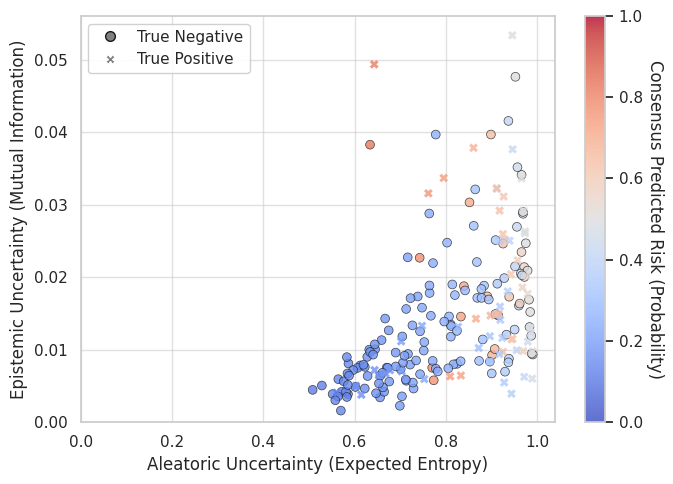

In [13]:
"""Uncertainty phase-plane plot"""
uncertainty_results['label'] = patients_stats_filtered['label']
plot_uncertainty_phase_plane_with_labels(uncertainty_results)

1. Validation of the Aleatoric Uncertainty (The "Borderline" Zone)

    The most crucial finding in this plot is the vertical band on the far right ($\text{Aleatoric} > 0.8$). In this region, the colors are mostly white, pale blue, and light red, indicating consensus predictions hovering near the decision boundary ($\approx 0.5$). Crucially, when we look at the markers in this exact zone, we see a highly intermixed population of both circles (True Negatives) and crosses (True Positives).
    - Interpretation: This mathematically validates your model's high aleatoric uncertainty. The model is outputting probabilities near 0.5 not because it is poorly trained, but because the baseline feature profiles of these patients are genuinely ambiguous. Patients who developed the complication and those who did not share nearly identical baseline representations in your feature space.

2. Confident Predictions vs. Confident Errors

    Look at the bottom-left quadrant ($\text{Aleatoric} < 0.7$, $\text{Epistemic} < 0.02$, dark blue color): The Successes: This area is heavily populated by blue circles. The model is highly confident these patients are low-risk, the models unanimously agree (near-zero epistemic), and the model is correct. 
    - The "Blind Spots" (Confident False Negatives): Within this same blue cluster, you can spot several blue crosses. These are patients the model confidently predicted as low-risk, but who actually developed the complication. Because both aleatoric and epistemic uncertainties are low, the models learned a clear rule that classified these patients as negative. This implies these specific patients either experienced a non-linear disease progression not predictable from baseline data, or their true risk is driven by unmeasured clinical variables entirely absent from your dataset.

3. The Role of Epistemic Uncertainty in True Positives

    Notice the distribution of the crosses (True Positives) versus the circles (True Negatives):The true negatives (circles) generally cluster tighter at the bottom.Many of the true positives (crosses), particularly the ones correctly predicted with high risk (red/orange), are scattered higher along the Epistemic Y-axis (e.g., the prominent orange cross at $\approx 0.053$). 
    - Interpretation: While overall epistemic uncertainty remains mathematically negligible ($< 0.06$), the models exhibit comparatively more disagreement when identifying positive cases than negative ones. This suggests that the feature patterns leading to motor complications are more varied or slightly underrepresented in the training splits compared to the highly consistent patterns of the negative class.


It justifies the argument that to push performance further, the field needs richer, more discriminative feature sets (e.g., longitudinal changes, novel biomarkers) rather than just larger quantities of the same baseline clinical scores.

## H Total analysis

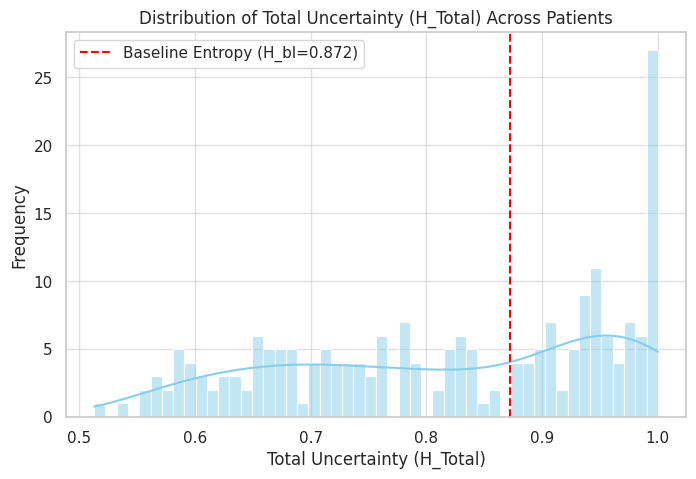

In [14]:
""" 
- if H_Total > H_bl then the models think the outcome is more uncertain than a random guess. This often signals a contradictory case ( patients who looks healthy but has risk factors). Model is less confidence than the baseline.

- if H_total << H_bl then the further the value drops below 0.871 , the more information the model has found to distinguish this patient from the average

- if H_total = 0.871 then we have a naive guess, the model guesses based on the general population prevalence. 

H_baseline - H_total -> Information Gain (IG)

"""



# histogram plot of Htotal for all patients
plt.figure(figsize=(8, 5))
sns.histplot(uncertainty_results['H_Total'], bins=50, kde=True, color='skyblue')
plt.axvline(H_bl, color='red', linestyle='--', label=f'Baseline Entropy (H_bl={H_bl:.3f})')
plt.title('Distribution of Total Uncertainty (H_Total) Across Patients')
plt.xlabel('Total Uncertainty (H_Total)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Aleatoric uncertainty (C)

(How useless are the features for this patient?)
Here we visualize the signal-to-noise gap. The difference between the baseline H and the patient's aleatoric uncertainty represents the predictive power of our features for that patient.

- The "Invisible" Patient: If a patient has C_h near 0 (Low Noise) but H_tot near 1 (High Total), it proves the "Invisible" problem is Epistemic. The data is clear, but the models fundamentally disagree on how to interpret it. 

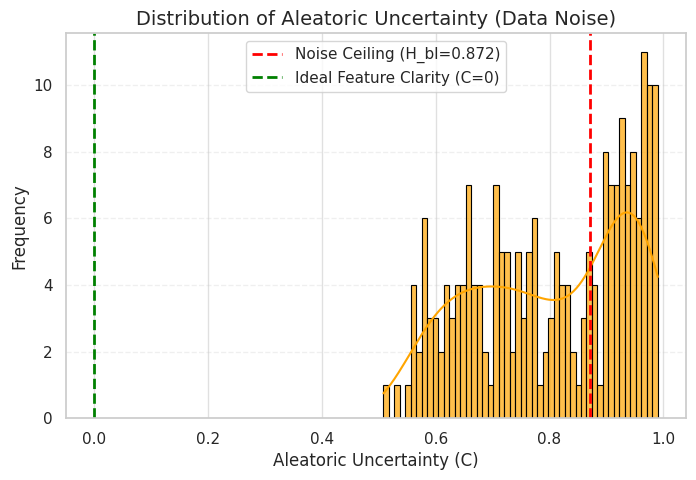

In [15]:
plt.figure(figsize=(8, 5))

# Plot the distribution of Aleatoric Uncertainty (Data Noise)
sns.histplot(uncertainty_results['C_Aleatoric'], bins=50, kde=True, color='orange', edgecolor='black', alpha=0.7)
# Add the Baseline Entropy Reference Line (The "Noise Ceiling")
plt.axvline(H_bl, color='red', linestyle='--', linewidth=2, label=f'Noise Ceiling (H_bl={H_bl:.3f})')
# Add the "Ideal" Reference Line (Zero Noise)
plt.axvline(0, color='green', linestyle='--', linewidth=2, label='Ideal Feature Clarity (C=0)')
plt.title('Distribution of Aleatoric Uncertainty (Data Noise)', fontsize=14)
plt.xlabel('Aleatoric Uncertainty (C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

The distribution of Aleatoric Uncertainty ($C$) is heavily skewed to the right, clustering dangerously close to your Noise Ceiling ($H_{bl} \approx 0.964$).

1. The "Feature Failure": The bulk of your patients (the tallest orange bars) are clustered between 0.90 and 0.964.Interpretation: For these patients, your clinical features (motor scores, medication, etc.) are providing almost zero predictive power. The models are "seeing" these patients as indistinguishable from the population baseline. 

[This proves that the "Invisible" patients are not just invisible to the model; they are invisible to the features. Their clinical profile is effectively random noise with respect to the outcome.]

2. The Missing "Signal" Observation: Look at the massive empty space on the left side (between the Green Line at 0.0 and the start of your data around 0.5).  You have almost no patients where the data is "clear" (Low Noise). In a strong predictive model, you would expect a bell curve centered around 0.4 or 0.5. Instead, your "best" patients start at 0.5 (which is still 50% noise). 

[Your current feature set is "weak." It lacks the discriminative power to separate "Healthy" from "Sick" with high confidence.]

## Epistemic uncertainty 

- Low $I$ (Near 0): This means the models agree. If $C$ is high (as we saw) and $I$ is low, it means the models have formed a "consensus of ignorance." They all agree that the patient is indistinguishable from the baseline.

- High $I$ (Right Skew): This means the models disagree. Even though the data is noisy, different models are finding different "weak signals." This is where you might find your "Invisible" patients who are being misclassified because the models are confused by their specific profile.

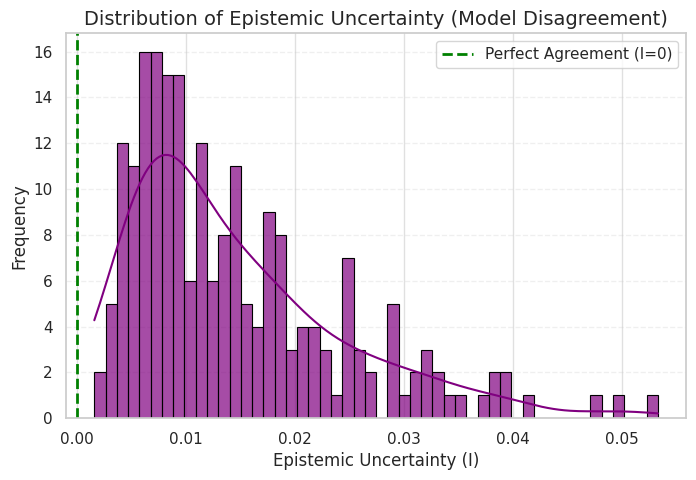

In [16]:

plt.figure(figsize=(8, 5))

# Plot the distribution of Epistemic Uncertainty (Model Disagreement)
sns.histplot(uncertainty_results['I_Epistemic'], bins=50, kde=True, color='purple', edgecolor='black', alpha=0.7)

# Add reference line at 0 (Perfect Agreement)
plt.axvline(0, color='green', linestyle='--', linewidth=2, label='Perfect Agreement (I=0)')

# We don't use H_bl here because Epistemic uncertainty isn't bounded by the prevalence in the same way.
# Instead, we look at the magnitude relative to 0.

plt.title('Distribution of Epistemic Uncertainty (Model Disagreement)', fontsize=14)
plt.xlabel('Epistemic Uncertainty (I)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## Accuracy-Rejection Curves (ARCs)

If we reject the most uncertain patients (those near the 0.964 line), does the accuracy for the remaining patients actually go up?
- f the curve is steep: It proves your uncertainty metrics are high-quality. Even though the noise is high, the model correctly "knows" which patients are the riskiest to predict.

- If the curve is flat: It suggests the noise is so pervasive that the uncertainty score isn't helpful for distinguishing correct from incorrect predictions.

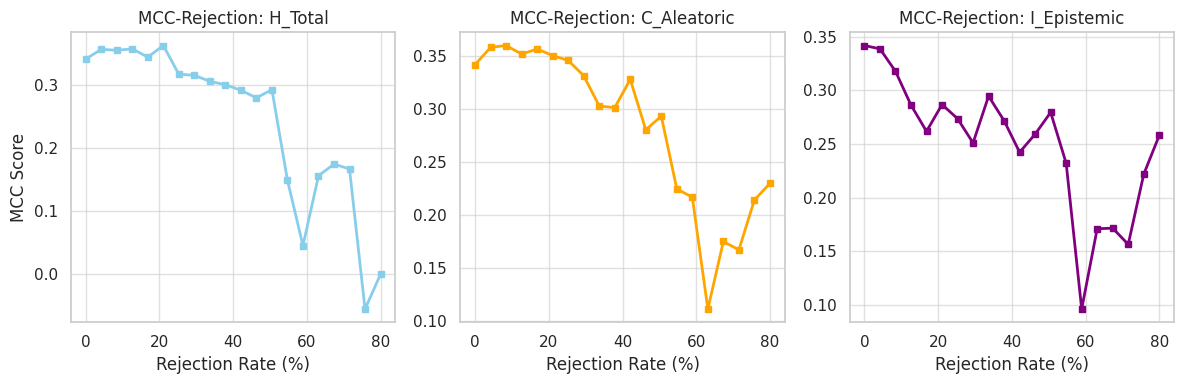

In [17]:
plot_mcc_rejection_curves(uncertainty_results, all_patients_non_active['FutureDyskinesia'])

PLOT FOR SHORT PAPER

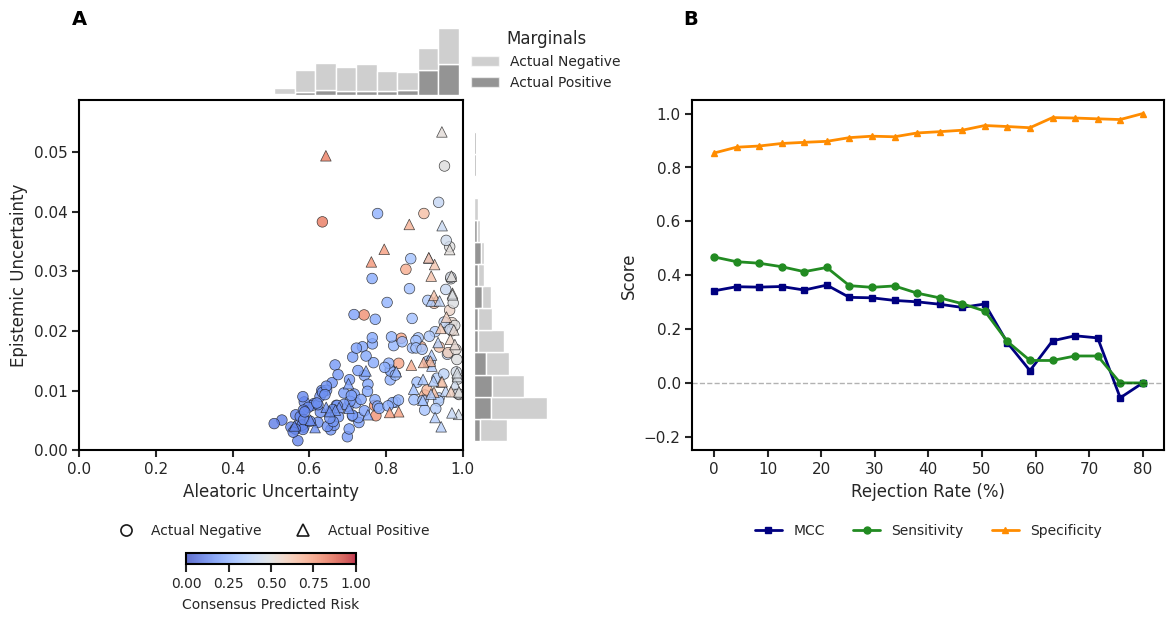

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import matplotlib.gridspec as gridspec

def plot_combined_uncertainty_analysis(uncertainty_df, y_true, save_path=None):
    # --- Configuration (Synchronized with Phenotype Template) ---
    border_width = 1.5
    base_fontsize = 10
    rc_params = {
        "axes.linewidth": border_width,
        "xtick.major.width": border_width,
        "ytick.major.width": border_width,
        "font.size": base_fontsize,
        "axes.edgecolor": "black"
    }
    sns.set_theme(style="ticks", rc=rc_params)
    
    fig = plt.figure(figsize=(14, 7))
    fig.set_facecolor('white')
    
    gs_master = gridspec.GridSpec(1, 2, wspace=0.3)

    # ---------------------------------------------------------
    # --- Subplot A: Phase-Plane ---
    # ---------------------------------------------------------
    gs_left = gridspec.GridSpecFromSubplotSpec(
        5, 2, subplot_spec=gs_master[0],
        height_ratios=[0.2, 1, 0.15, 0.10, 0.03], 
        width_ratios=[1, 0.2], 
        hspace=0.05, wspace=0.05
    )
    
    ax_main = fig.add_subplot(gs_left[1, 0])
    ax_hist_x = fig.add_subplot(gs_left[0, 0], sharex=ax_main)
    ax_hist_y = fig.add_subplot(gs_left[1, 1], sharey=ax_main)
    
    # New Axis for the Marginal Legend in the empty top-right corner
    ax_legend_marginal = fig.add_subplot(gs_left[0, 1])
    ax_legend_marginal.axis('off')
    
    # Bottom Legend Axis
    ax_legend_a = fig.add_subplot(gs_left[3, 0])
    ax_legend_a.axis('off')

    gs_cbar_container = gridspec.GridSpecFromSubplotSpec(
        1, 3, subplot_spec=gs_left[4, 0], width_ratios=[0.25, 0.5, 0.25]
    )
    ax_cbar = fig.add_subplot(gs_cbar_container[0, 1])

    # Plotting Data
    markers_map = {0: 'o', 1: '^'}
    color_tn, color_tp = '#b0b0b0', '#4d4d4d' 
    scatter_plot = None
    
    for true_class in [0, 1]:
        subset = uncertainty_df[uncertainty_df['label'] == true_class]
        if subset.empty: continue
        scatter = ax_main.scatter(
            subset['C_Aleatoric'], subset['I_Epistemic'], 
            c=subset['Final_Calibrated_Prob'], cmap='coolwarm', 
            vmin=0, vmax=1, alpha=0.8, edgecolors='k', linewidths=0.5,
            s=58, marker=markers_map[true_class]
        )
        scatter_plot = scatter

    ax_main.set_xlim(0, 1)
    ax_main.set_ylim(0, uncertainty_df['I_Epistemic'].max() * 1.1)

    # Marginal Histograms (Stacked)
    sns.histplot(data=uncertainty_df, x='C_Aleatoric', hue='label', ax=ax_hist_x, 
                 palette={0: color_tn, 1: color_tp}, multiple="stack", alpha=0.6, legend=False)
    sns.histplot(data=uncertainty_df, y='I_Epistemic', hue='label', ax=ax_hist_y, 
                 palette={0: color_tn, 1: color_tp}, multiple="stack", alpha=0.6, legend=False)

    # Upper Right Legend for Marginal Histograms (Outside Main Plot)
    marginal_legend_elements = [
        Patch(facecolor=color_tn, alpha=0.6, label='Actual Negative'),
        Patch(facecolor=color_tp, alpha=0.6, label='Actual Positive')
    ]
    ax_legend_marginal.legend(handles=marginal_legend_elements, loc='center left', 
                              bbox_to_anchor=(-0.2, 0.5), frameon=False, fontsize=base_fontsize, title='Marginals')

    # Legend A (Bottom) - Hollow Shapes Only
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Actual Negative', 
               markerfacecolor='none', markersize=8, markeredgecolor='k', markeredgewidth=1.2),
        Line2D([0], [0], marker='^', color='w', label='Actual Positive',
               markerfacecolor='none', markersize=8, markeredgecolor='k', markeredgewidth=1.2)
    ]
    ax_legend_a.legend(handles=legend_elements, loc='center', ncol=2, frameon=False, fontsize=base_fontsize)

    # ---------------------------------------------------------
    # --- Subplot B: Rejection Curves ---
    # ---------------------------------------------------------
    gs_right = gridspec.GridSpecFromSubplotSpec(
        5, 1, subplot_spec=gs_master[1],
        height_ratios=[0.2, 1, 0.15, 0.10, 0.03], hspace=0.05
    )
    ax_b = fig.add_subplot(gs_right[1, 0])
    
    ax_legend_b = fig.add_subplot(gs_right[3, 0])
    ax_legend_b.axis('off')
    
    y_pred_class = (uncertainty_df['Final_Calibrated_Prob'] > 0.5).astype(int)
    sorted_indices = uncertainty_df['H_Total'].sort_values(ascending=False).index
    rejection_rates = np.linspace(0, 0.80, 20)
    
    mcc_scores, sens_scores, spec_scores = [], [] ,[]
    for rate in rejection_rates:
        n_rejected = int(len(sorted_indices) * rate)
        idx = sorted_indices[n_rejected:]
        if len(np.unique(y_true.loc[idx])) < 2:
            mcc_scores.append(np.nan); sens_scores.append(np.nan); spec_scores.append(np.nan)
        else:
            y_t, y_p = y_true.loc[idx], y_pred_class.loc[idx]
            mcc_scores.append(matthews_corrcoef(y_t, y_p))
            tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
            sens_scores.append(tp/(tp+fn)); spec_scores.append(tn/(tn+fp))

    ax_b.plot(rejection_rates*100, mcc_scores, marker='s', color='navy', 
              linewidth=2, markersize=5, label='MCC')
    ax_b.plot(rejection_rates*100, sens_scores, marker='o', color='forestgreen', 
              linewidth=2, markersize=5, label='Sensitivity')
    ax_b.plot(rejection_rates*100, spec_scores, marker='^', color='darkorange', 
              linewidth=2, markersize=5, label='Specificity')
    
    ax_b.set_ylim(-0.25, 1.05) 
    ax_b.axhline(0, color='black', lw=1, ls='--', alpha=0.3)
    
    handles, labels = ax_b.get_legend_handles_labels()
    ax_legend_b.legend(handles=handles, labels=labels, loc='center', ncol=3, frameon=False, fontsize=base_fontsize)

    # ---------------------------------------------------------
    # --- Final Formatting & Thickness Enforcement ---
    # ---------------------------------------------------------
    for ax in [ax_main, ax_b]:
        for spine in ax.spines.values():
            spine.set_linewidth(border_width)
        ax.tick_params(width=border_width, length=5)
        ax.grid(False)

    for ax_h in [ax_hist_x, ax_hist_y]:
        ax_h.axis('off')

    cbar = fig.colorbar(scatter_plot, cax=ax_cbar, orientation='horizontal')
    cbar.outline.set_linewidth(border_width)
    cbar.ax.tick_params(width=border_width, labelsize=base_fontsize)
    cbar.set_label('Consensus Predicted Risk', fontsize=base_fontsize, labelpad=5)

    ax_main.set_xlabel('Aleatoric Uncertainty')
    ax_main.set_ylabel('Epistemic Uncertainty')
    ax_b.set_xlabel('Rejection Rate (%)')
    ax_b.set_ylabel('Score')

    ax_hist_x.text(-0.02, 1.0, 'A', transform=ax_hist_x.transAxes, 
                   fontsize=14, fontweight='bold', color='black')
    
    ax_b_header = fig.add_subplot(gs_right[0, 0])
    ax_b_header.axis('off')
    ax_b_header.text(-0.02, 1.0, 'B', transform=ax_b_header.transAxes, 
                     fontsize=14, fontweight='bold', color='black')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_combined_uncertainty_analysis(uncertainty_results, all_patients_non_active['FutureDyskinesia'])


What if we divide patients based on how much ledd they were given at baseline and we plot the two ARCs?

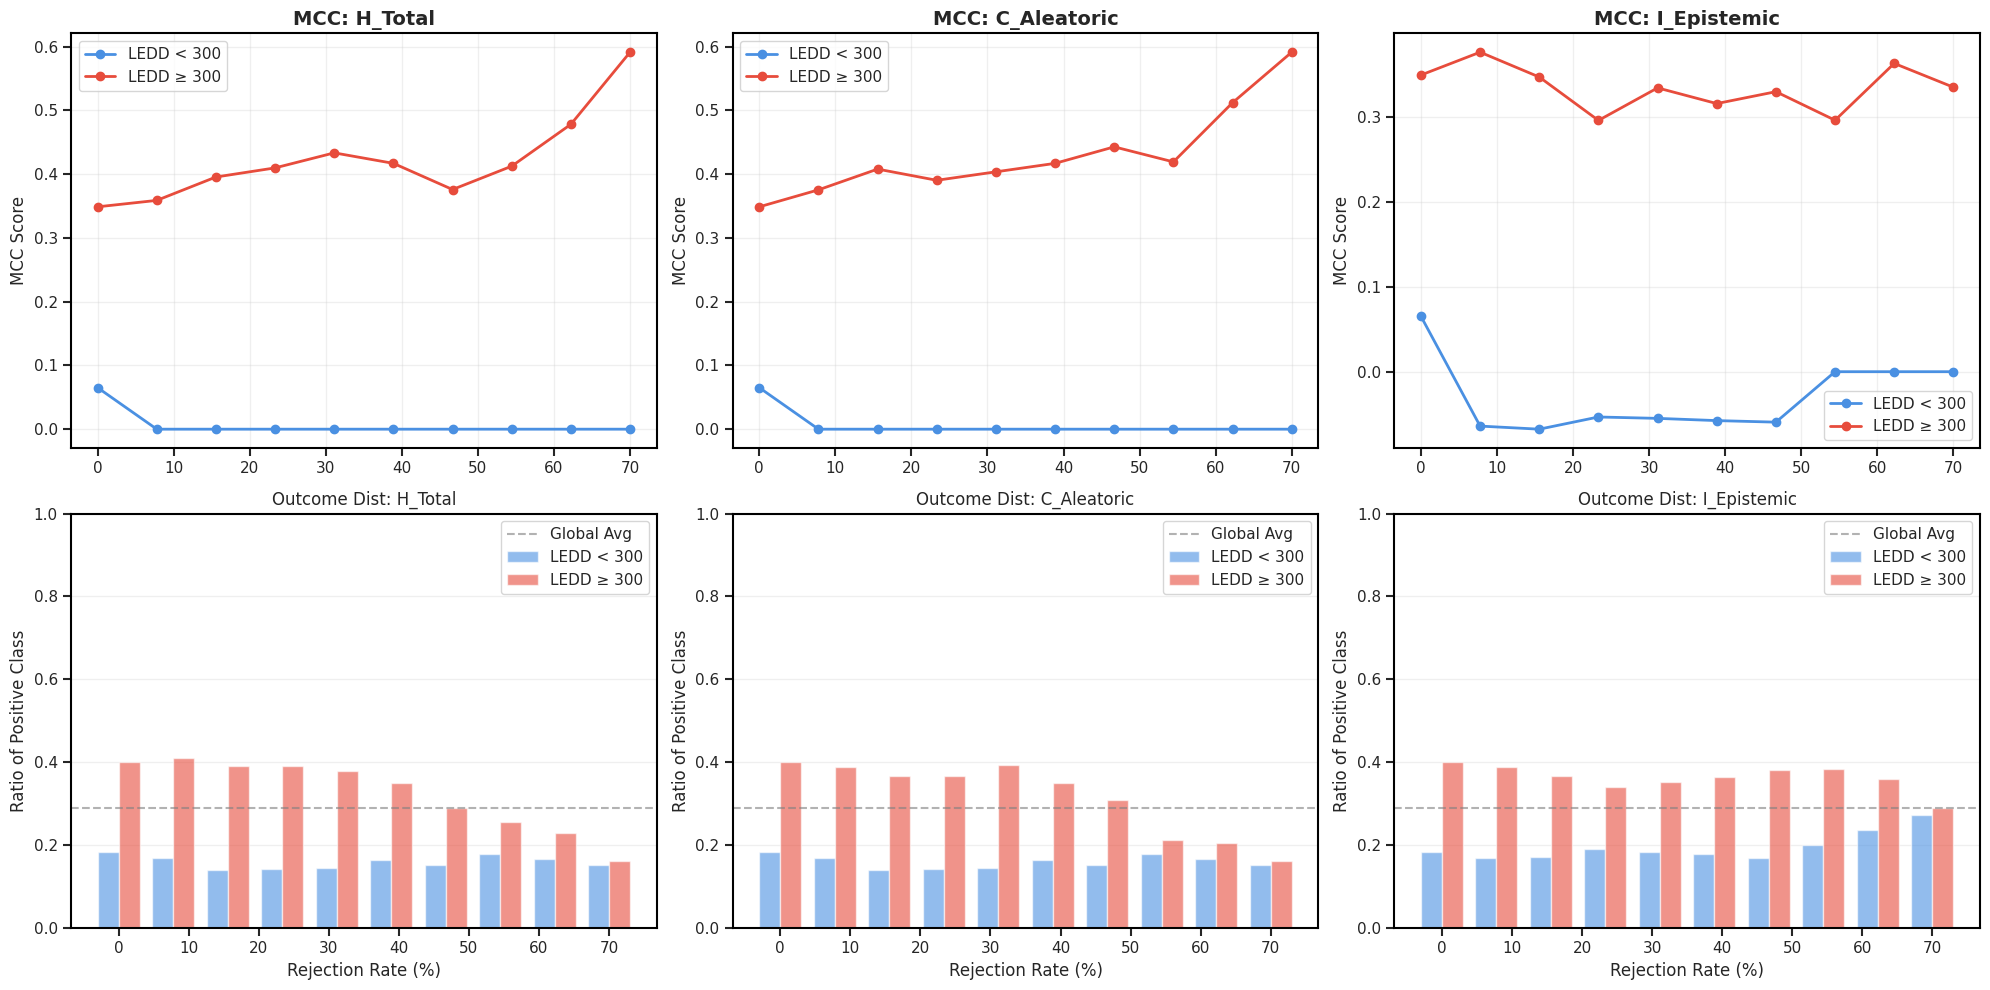

In [20]:
plot_mcc_rejection_with_distribution(
    uncertainty_results,
    all_patients_non_active['FutureDyskinesia'],
    probs_raw_df.mean(axis=1),
    all_patients_non_active['ledd'],
    thr_ledd=300
)

## Second part

Instead of using a clinical label, we try to run unsupervised clustering to see if we can find two or more different clinical phenotypes, then we analyze how our deep ensemble performs on them

In [14]:
""" Functions """



def optimize_pca_and_gmm_kaiser(X_clinical, max_clusters=6):
    """
    Finds the optimal number of PCs using the Kaiser Rule (Eigenvalue > 1) 
    and the optimal number of GMM clusters based on those PCs.
    """
    # ==========================================
    # STEP 0: Preprocessing
    # ==========================================
    imputer = SimpleImputer(strategy='median')
    # Scaling is mandatory for the Kaiser rule so total variance = number of features
    X_scaled = StandardScaler().fit_transform(imputer.fit_transform(X_clinical))
    
    # ==========================================
    # STEP 1: Optimize PCA (Kaiser Rule)
    # ==========================================
    pca_full = PCA()
    pca_full.fit(X_scaled)
    
    # Calculate Eigenvalues (Explained variance for standard-scaled data)
    eigenvalues = pca_full.explained_variance_

    # The Kaiser Rule: Keep PCs with eigenvalue > 1
    n_components_opt = np.sum(eigenvalues > 1.0)

    print(f"Number of original clinical features: {X_scaled.shape[1]}")
    print(f"Optimal PCs according to the Kaiser Rule: {n_components_opt}")
    print("\nTop 5 Eigenvalues:")
    print(np.round(eigenvalues[:5], 2))
    
    # ==========================================
    # STEP 2: Optimize GMM (using Kaiser-optimal PCs)
    # ==========================================
    pca_opt = PCA(n_components=n_components_opt, random_state=42)
    X_pca = pca_opt.fit_transform(X_scaled)
    
    bics = []
    silhouettes = []
    k_range = range(2, max_clusters + 1)
    
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
        labels = gmm.fit_predict(X_pca)
        
        bics.append(gmm.bic(X_pca))
        silhouettes.append(silhouette_score(X_pca, labels))
        
    # ==========================================
    # PLOTTING THE JUSTIFICATION DASHBOARD
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.set_facecolor('white')
    
    # Plot 1: True Scree Plot (Eigenvalues)
    axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', lw=2, color='#3498DB')
    axes[0].axhline(y=1.0, color='gray', linestyle='--', label='Kaiser Threshold (Eigenvalue = 1.0)')
    axes[0].axvline(x=n_components_opt, color='#E74C3C', linestyle='--', label=f'Optimal PCs: {n_components_opt}')
    axes[0].set_title('Step 1: PCA Scree Plot (Eigenvalues)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Eigenvalue (Variance)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: GMM BIC Score
    axes[1].plot(k_range, bics, marker='s', lw=2, color='#E67E22')
    axes[1].set_title(f'Step 2: GMM BIC Score\n(Using {n_components_opt} PCs)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('BIC Score (LOWER is better)')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: GMM Silhouette Score
    axes[2].plot(k_range, silhouettes, marker='^', lw=2, color='#2ECC71')
    axes[2].set_title(f'Step 3: GMM Silhouette Score\n(Using {n_components_opt} PCs)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Number of Clusters (k)')
    axes[2].set_ylabel('Silhouette Score (HIGHER is better)')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- Optimization Results ---")
    print(f"1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): {n_components_opt}")
    print(f"2. Best GMM model according to BIC (lowest complexity penalty): k = {k_range[np.argmin(bics)]}")
    print(f"3. Best GMM model according to Silhouette (highest separation): k = {k_range[np.argmax(silhouettes)]}")


def profile_clinical_clusters(X_clinical, analysis_df):
    """
    Compares the clinical features between the two discovered phenotypes.
    """
    # 1. Ensure X_clinical and the cluster labels are aligned
    df_compare = X_clinical.copy()
    df_compare['Phenotype'] = analysis_df['Phenotype'].values
    
    # 2. Initialize a list to store our results
    results = []
    
    # 3. Iterate through each clinical feature to compare the two groups
    features = [col for col in df_compare.columns if col != 'Phenotype']
    
    for feature in features:
        # Get data for each phenotype
        group_A = df_compare[df_compare['Phenotype'] == 'Phenotype A (Predictable - advanced)'][feature].dropna()
        group_B = df_compare[df_compare['Phenotype'] == 'Phenotype B (Invisible - mild)'][feature].dropna()
        
        # Skip if a group is empty
        if len(group_A) == 0 or len(group_B) == 0:
            continue
            
        # Calculate Means
        mean_A = group_A.mean()
        mean_B = group_B.mean()
        
        # Statistical Test (Mann-Whitney U is robust for non-normal clinical data)
        stat, p_val = mannwhitneyu(group_A, group_B, alternative='two-sided')
        
        results.append({
            'Clinical_Feature': feature,
            'Mean_Phenotype_A': round(mean_A, 2),
            'Mean_Phenotype_B': round(mean_B, 2),
            'P_Value': p_val
        })
        
    # 4. Create a DataFrame and sort by the most significant differences
    profile_df = pd.DataFrame(results)
    profile_df.sort_values('P_Value', inplace=True)
    
    # Format P-value for readability
    profile_df['P_Value'] = profile_df['P_Value'].apply(lambda x: '<0.001' if x < 0.001 else round(x, 4))
    
    print("--- Clinical Signature of the Phenotypes ---")
    print(profile_df.head(10).to_string(index=False)) # Show top 10 most different features
    
    return profile_df

# --- Configuration ---
PALETTE = {0.0: '#3498DB', 1.0: '#E74C3C'} # Bright Blue / Red
RATES_TO_SHOW = [0, 25, 50] # The rejection "snapshots" for scatter plots
MCC_RANGE = np.arange(0, 61, 5) # The full range for the metrics curve at the bottom
BASE_FONT_SIZE = 11
plt.rcParams.update({'font.size': BASE_FONT_SIZE, 'axes.grid': False})

def calculate_metrics_series(df, uncertainty_col, rates):
    """Helper to calculate MCC, Sensitivity, and Specificity curve data."""
    mcc_scores = []
    sensitivities = []
    specificities = []
    
    # Create the binary prediction column if it doesn't exist
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    for rate in rates:
        n_reject = int(len(df) * (rate / 100.0))
        if n_reject > 0:
            kept = df.sort_values(by=uncertainty_col, ascending=False).iloc[n_reject:]
        else:
            kept = df
        
        y_true = kept['label']
        y_pred = kept['y_pred']
        
        # Calculate MCC
        if len(y_true.unique()) > 1:
            mcc = matthews_corrcoef(y_true, y_pred)
        else:
            mcc = 0.0
            
        # Calculate Sensitivity & Specificity
        if len(y_true) > 0:
            # Safely calculate confusion matrix even if one class is entirely rejected
            labels_present = np.unique(np.concatenate((y_true, y_pred)))
            if len(labels_present) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            else:
                tp = sum((y_true == 1) & (y_pred == 1))
                tn = sum((y_true == 0) & (y_pred == 0))
                fp = sum((y_true == 0) & (y_pred == 1))
                fn = sum((y_true == 1) & (y_pred == 0))
                
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        else:
            sens, spec = 0.0, 0.0
            
        mcc_scores.append(mcc)
        sensitivities.append(sens)
        specificities.append(spec)
        
    return rates, mcc_scores, sensitivities, specificities

def plot_enhanced_scatter(ax, df, rate, max_uncertainty, uncertainty_col):
    """Plots scatter with crucial fix: RED DOTS ON TOP. Dynamically maps Y-axis."""
    # Split data by class
    df_healthy = df[df['label'] == 0.0]
    df_incident = df[df['label'] == 1.0]
    
    # 1. Plot Healthy (Background, Transparent)
    ax.scatter(
        df_healthy['mu'], df_healthy[uncertainty_col], c=PALETTE[0.0], 
        alpha=0.3, s=40, edgecolor='none', zorder=1
    )
    
    # 2. Plot Incident (Foreground, Opaque, Larger edges)
    ax.scatter(
        df_incident['mu'], df_incident[uncertainty_col], c=PALETTE[1.0], 
        alpha=1.0, s=55, edgecolor='white', linewidth=0.8, zorder=2
    )
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.01, max_uncertainty)
    ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=1, zorder=0)
    ax.text(0.05, max_uncertainty*0.85, f'Rate: {rate}%\nN={len(df)}', fontsize=10, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_metrics_context(ax, rates, mcc_scores, sensitivities, specificities):
    """Plots the MCC, Sensitivity, and Specificity curves with markers."""
    # Plot the three lines with distinct styles
    ax.plot(rates, mcc_scores, color='#555555', linewidth=3, marker='o', markersize=6, label='MCC')
    ax.plot(rates, sensitivities, color='#E74C3C', linewidth=2, linestyle='--', marker='s', markersize=5, label='Sensitivity (TP Rate)')
    ax.plot(rates, specificities, color='#3498DB', linewidth=2, linestyle='-.', marker='^', markersize=5, label='Specificity (TN Rate)')
    
    ax.set_ylim(-0.05, 1.05) # Standardize scale to fit Sensitivity/Specificity
    ax.set_xlim(0, 60)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.set_ylabel('Metric Score')
    ax.set_xlabel('Rejection Rate (%)')
    
    # Add vertical lines linking to the scatter plots above
    for r in RATES_TO_SHOW:
        ax.axvline(x=r, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
        
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9, ncol=1)

def generate_forensic_dashboard(df, uncertainty_col='sigma'):
    phenotypes = ['Phenotype A (Predictable - advanced)', 'Phenotype B (Invisible - mild)']
    
    # Dictionary to format Y-axis labels dynamically
    axis_labels = {
        'sigma': 'Std Dev (σ)',
        'C_Aleatoric': 'Aleatoric Uncertainty (C)',
        'H_Total': 'Total Uncertainty (H)',
        'I_Epistemic': 'Epistemic Uncertainty (I)'
    }
    y_axis_label = axis_labels.get(uncertainty_col, uncertainty_col)
    
    fig = plt.figure(figsize=(14, 12))
    fig.set_facecolor('white')
    outer_grid = GridSpec(1, 2, figure=fig, wspace=0.25, width_ratios=[1, 1])
    
    max_uncertainty = df[uncertainty_col].max() * 1.1
    
    # --- Main Loop through Phenotypes (Columns) ---
    for i, pheno in enumerate(phenotypes):
        inner_grid = GridSpecFromSubplotSpec(4, 1, subplot_spec=outer_grid[i], 
                                             height_ratios=[1, 1, 1, 1.5], hspace=0.4)
        pheno_df = df[df['Phenotype'] == pheno].copy()
        
        # Title for the whole column
        col_title = f"{pheno}\n({'moderate-to-advanced patients' if i==0 else 'early-stage patients'})"
        fig.text(0.28 + i*0.44, 0.92, col_title, ha='center', fontsize=16, fontweight='bold')

        # --- Rows 1-3: Scatter Plot Evolution ---
        for j, rate in enumerate(RATES_TO_SHOW):
            ax = plt.Subplot(fig, inner_grid[j])
            n_drop = int(len(pheno_df) * (rate / 100))
            if n_drop > 0:
                subset = pheno_df.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop:]
            else:
                subset = pheno_df
                
            # Pass the uncertainty_col to the plotting function
            plot_enhanced_scatter(ax, subset, rate, max_uncertainty, uncertainty_col)
            
            # Dynamically set the Y-axis label
            if i == 0: ax.set_ylabel(y_axis_label)
            if j == 2: ax.set_xlabel('Mean Probability (μ)')
            fig.add_subplot(ax)
            
        # --- Row 4: Metrics Curve Context ---
        ax_metrics = plt.Subplot(fig, inner_grid[3])
        rates, mcc_scores, sens_scores, spec_scores = calculate_metrics_series(pheno_df, uncertainty_col, MCC_RANGE)
        
        plot_metrics_context(ax_metrics, rates, mcc_scores, sens_scores, spec_scores) 
        if i == 1: ax_metrics.set_ylabel('')
        fig.add_subplot(ax_metrics)

    # --- Custom Legend ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Healthy (y=0, Background)', 
               markerfacecolor=PALETTE[0.0], markersize=12, alpha=0.6),
        Line2D([0], [0], marker='o', color='w', label='Progressor (y=1, Foreground)', 
               markerfacecolor=PALETTE[1.0], markersize=12, markeredgecolor='k'),
        Line2D([0], [0], color='gray', linestyle=':', linewidth=2, label='Rejection Snapshots shown above')
    ]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.02), 
               frameon=False, ncol=3, fontsize=12)
    
    plt.subplots_adjust(top=0.9, bottom=0.1)
    plt.show()

def explore_confusion_matrix_evolution(df, uncertainty_col='H_Total', rates=[0, 25, 50]):
    """
    Calculates the exact TP, TN, FP, FN, and MCC at specific rejection rates 
    to prove why the model collapses on Phenotype B but survives on Phenotype A.
    """
    results = []
    # Make sure we have a binary prediction column
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    phenotypes = sorted(df['Phenotype'].unique())
    
    for pheno in phenotypes:
        pheno_df = df[df['Phenotype'] == pheno].copy()
        
        for rate in rates:
            # Calculate rejection threshold
            n_drop = int(len(pheno_df) * (rate / 100.0))
            if n_drop > 0:
                kept = pheno_df.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop:]
            else:
                kept = pheno_df
                
            y_true = kept['label']
            y_pred = kept['y_pred']
            
            # Safely calculate confusion matrix even if classes are missing
            labels_present = np.unique(np.concatenate((y_true, y_pred)))
            if len(labels_present) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
                mcc = matthews_corrcoef(y_true, y_pred)
            else:
                # If only one class is predicted/present, MCC is 0 and we manually count
                tp = sum((y_true == 1) & (y_pred == 1))
                tn = sum((y_true == 0) & (y_pred == 0))
                fp = sum((y_true == 0) & (y_pred == 1))
                fn = sum((y_true == 1) & (y_pred == 0))
                mcc = 0.0
                
            results.append({
                'Phenotype': pheno[:11] + '...', # Shorten for clean display
                'Rejection (%)': rate,
                'Total Kept': len(kept),
                'True Positives (TP)': tp,
                'False Positives (FP)': fp,
                'True Negatives (TN)': tn,
                'False Negatives (FN)': fn,
                'MCC': round(mcc, 3)
            })
            
    # Format as a clean DataFrame
    results_df = pd.DataFrame(results)
    
    # Print formatted output for the presentation
    print("="*80)
    print("CONFUSION MATRIX EVOLUTION BY PHENOTYPE")
    print("="*80)
    print(results_df.to_string(index=False))
    print("="*80)
    
    return results_df

In [15]:
X_clinical = all_patients_non_active.drop(columns=['FutureDyskinesia', 'PatientID', 'Center', 
                                                   'FutureMotorFluctuations', 'max_status_longi', 'FutureFalls', 
                                                   'FutureFreezing'])

Number of original clinical features: 27
Optimal PCs according to the Kaiser Rule: 9

Top 5 Eigenvalues:
[4.28 2.9  1.9  1.65 1.4 ]


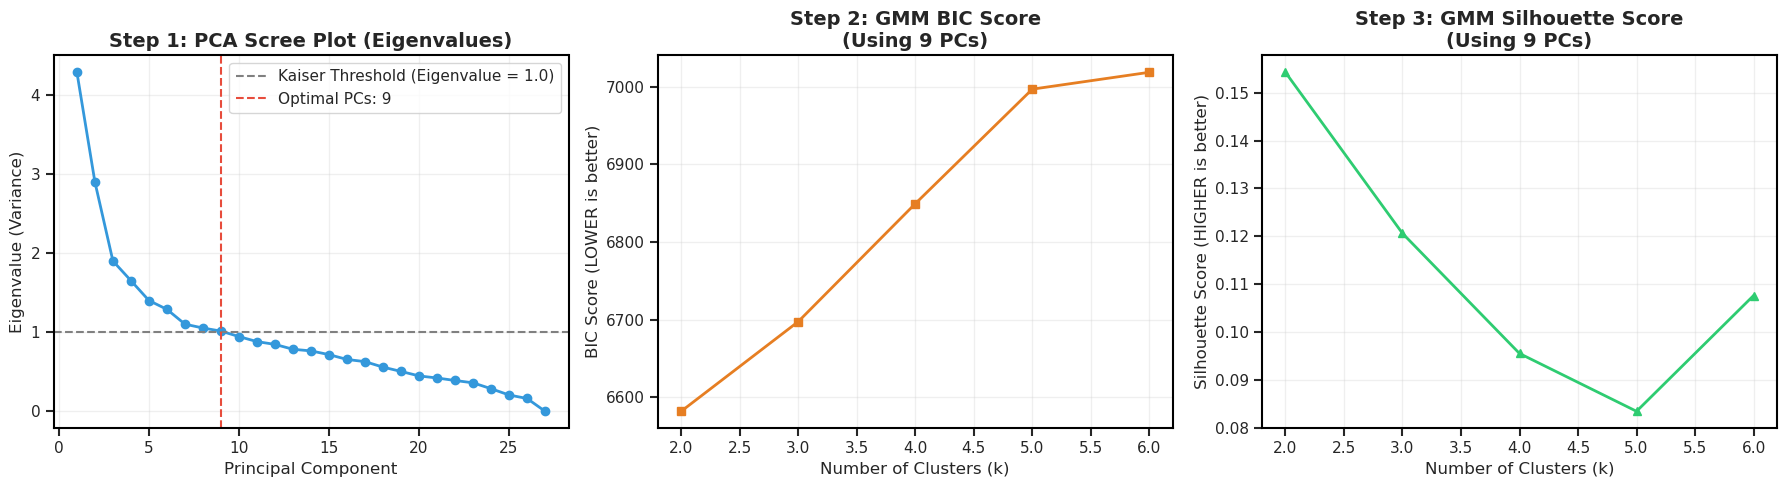


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 9
2. Best GMM model according to BIC (lowest complexity penalty): k = 2
3. Best GMM model according to Silhouette (highest separation): k = 2


In [16]:
optimize_pca_and_gmm_kaiser(X_clinical, max_clusters=6)

In [17]:
""" Run gmm clustering and analyze the two clusters"""

# 1. Prepare Data
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clinical)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca_opt = PCA(n_components=9, random_state=42)
X_pca = pca_opt.fit_transform(X_scaled)

final_gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
clusters = final_gmm.fit_predict(X_pca)

cluster_probs = final_gmm.predict_proba(X_pca)

phenotype_labels = np.where(clusters == 0, 'Phenotype A (Predictable - advanced)', 'Phenotype B (Invisible - mild)')



In [18]:
# analysis_df is the unc df + y_true + y_pred (as mu>0.5) + cluster labels (phenotypes) add also mean pred proba (mu) and std (sigma)

uncertainty_results['sigma'] = patients_stats_filtered['sigma']
uncertainty_results['y_pred'] = (uncertainty_results['Final_Calibrated_Prob'] > 0.5).astype(int)
uncertainty_results['label'] = patients_stats_filtered['label']
uncertainty_results.rename(columns={'Final_Calibrated_Prob':'mu'}, inplace=True)
uncertainty_results['Phenotype'] = phenotype_labels


In [19]:
clinical_profile = profile_clinical_clusters(X_clinical, uncertainty_results)

--- Clinical Signature of the Phenotypes ---
 Clinical_Feature  Mean_Phenotype_A  Mean_Phenotype_B P_Value
MotorFluctuations              0.38              0.02  <0.001
             ledd            449.56            164.35  <0.001
 DiseaseYearsAtBL              1.03              0.24  <0.001
         Freezing              0.27              0.00  <0.001
    LevodopaYears              4.30              1.15  <0.001
            Falls              0.26              0.00  <0.001
  CognitiveStatus              0.32              0.00  <0.001
              ICD              0.23              0.00  <0.001
   LevodopaBinary              0.87              0.53  <0.001
              H&Y              2.05              1.65  <0.001


## analyze ARCs curve on the two clusters

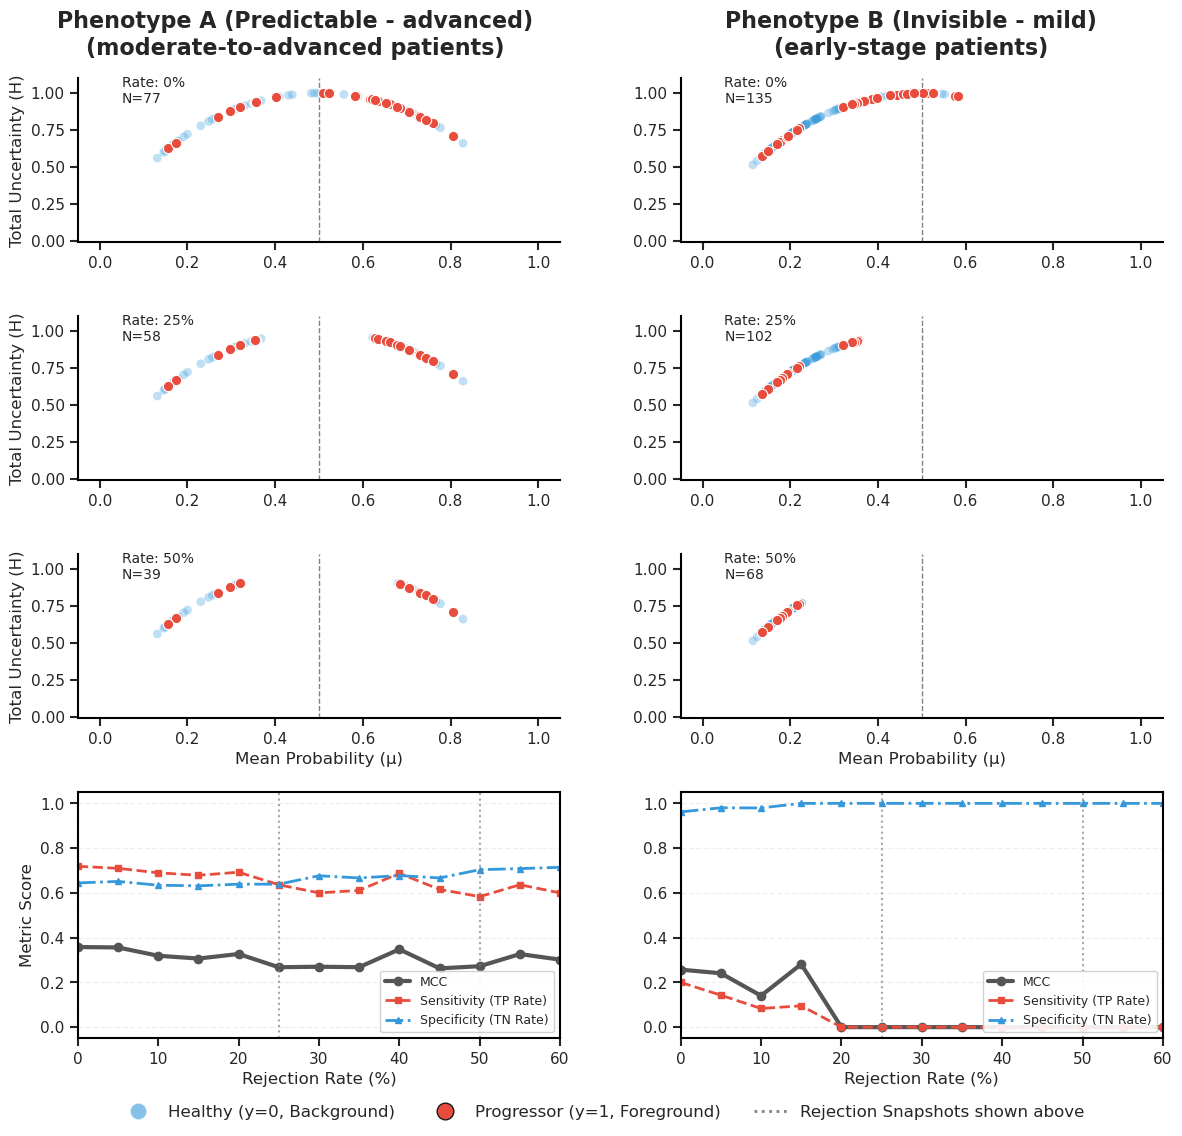

In [20]:
generate_forensic_dashboard(uncertainty_results, 'H_Total')

PLOT FOR SHORT PAPER

Metrics dashboard saved to ./images_rome/stratified_rejection.svg


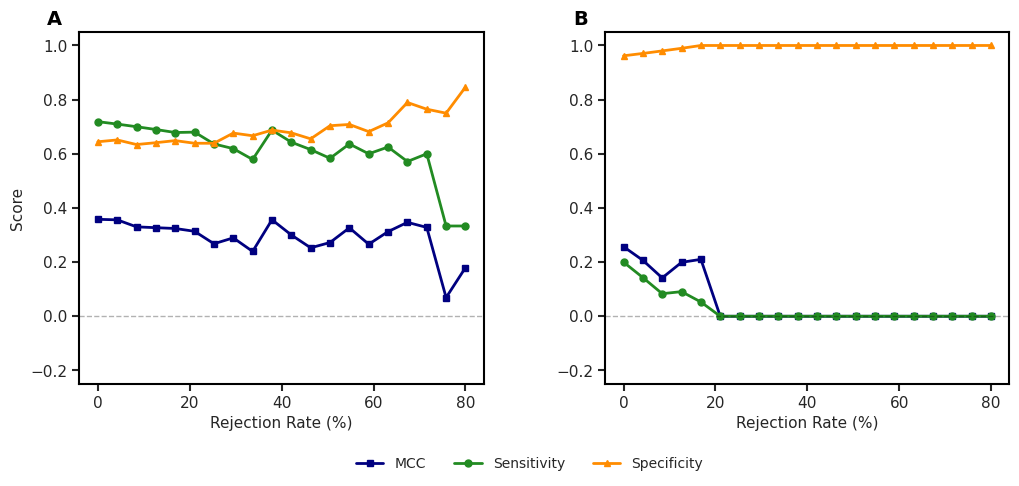

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.metrics import matthews_corrcoef, confusion_matrix

def plot_phenotype_metrics_comparison(df, uncertainty_col='H_Total', save_path=None):
    """
    Plots a side-by-side comparison of Metrics vs. Rejection Rate 
    with a single shared legend at the bottom.
    """
    # 1. Ensure necessary columns exist
    if 'label' not in df.columns or 'Phenotype' not in df.columns:
        raise ValueError("DataFrame must contain 'label' and 'Phenotype' columns.")
        
    if 'y_pred' not in df.columns:
        prob_col = 'mu' if 'mu' in df.columns else 'Final_Calibrated_Prob'
        df['y_pred'] = (df[prob_col] >= 0.5).astype(int)

    # --- 2. Visual Configuration ---
    border_width = 1.5
    rc_params = {
        "axes.linewidth": border_width,
        "xtick.major.width": border_width,
        "ytick.major.width": border_width,
        "font.size": 10,
        "axes.edgecolor": "black",
        "font.family": "sans-serif"
    }
    sns.set_theme(style="ticks", rc=rc_params)
    
    fig = plt.figure(figsize=(12, 5.5)) # Increased height slightly for bottom legend
    fig.set_facecolor('white')
    gs = gridspec.GridSpec(1, 2, wspace=0.3)
    
    phenotypes = sorted(df['Phenotype'].unique())[:2]
    labels = ['A', 'B']
    
    # Store line objects for the shared legend
    lines = []
    line_labels = []
    
    for i, pheno in enumerate(phenotypes):
        ax = plt.subplot(gs[i])
        ax.grid(False)
        
        for spine in ax.spines.values():
            spine.set_linewidth(border_width)
            
        ax.tick_params(bottom=True, left=True, width=border_width, length=5)
        
        pheno_df = df[df['Phenotype'] == pheno].copy()
        sorted_indices = pheno_df[uncertainty_col].sort_values(ascending=False).index
        
        rejection_rates = np.linspace(0, 0.80, 20)
        mccs, sens, specs = [], [], []
        
        for rate in rejection_rates:
            n_rejected = int(len(sorted_indices) * rate)
            accepted_indices = sorted_indices[n_rejected:]
            
            y_t = pheno_df.loc[accepted_indices, 'label']
            y_p = pheno_df.loc[accepted_indices, 'y_pred']
            
            if len(np.unique(y_t)) < 2:
                mccs.append(np.nan); sens.append(np.nan); specs.append(np.nan)
            else:
                tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
                mccs.append(matthews_corrcoef(y_t, y_p))
                sens.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
                specs.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
                
        # Plot lines
        l1 = ax.plot(rejection_rates * 100, mccs, marker='s', color='navy', 
                     linewidth=2, markersize=5, label='MCC')[0]
        l2 = ax.plot(rejection_rates * 100, sens, marker='o', color='forestgreen', 
                     linewidth=2, markersize=5, label='Sensitivity')[0]
        l3 = ax.plot(rejection_rates * 100, specs, marker='^', color='darkorange', 
                     linewidth=2, markersize=5, label='Specificity')[0]
        
        if i == 0:
            lines = [l1, l2, l3]
            line_labels = ['MCC', 'Sensitivity', 'Specificity']

        ax.set_title('', fontsize=12, fontweight='bold', pad=1)
        ax.set_xlabel('Rejection Rate (%)', fontsize=11)
        
        if i == 0:
            ax.set_ylabel('Score', fontsize=11)
            
        ax.set_ylim(-0.25, 1.05)
        ax.axhline(0, color='black', lw=1, ls='--', alpha=0.3)
            
        ax.text(-0.08, 1.02, labels[i], transform=ax.transAxes, 
                fontsize=14, fontweight='bold', color='black')

    # --- 3. Shared Legend at the Bottom ---
    # ncol=3 puts them in one row
    # loc='lower center' and bbox_to_anchor places it outside the axes
    fig.legend(lines, line_labels, loc='lower center', ncol=3, 
               fontsize=10, frameon=False,
               bbox_to_anchor=(0.5, -0.0))

    # Adjust layout to prevent clipping of the legend and labels
    plt.subplots_adjust(top=0.82, bottom=0.18) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Metrics dashboard saved to {save_path}")
        
    plt.show()
plot_phenotype_metrics_comparison(uncertainty_results, uncertainty_col='H_Total', save_path='./images_rome/stratified_rejection.svg')

Confusion matrix evolution

In [22]:
# --- Execution ---
# Using H_Total as the uncertainty metric since that was used in your latest plot
matrix_evolution = explore_confusion_matrix_evolution(uncertainty_results, uncertainty_col='H_Total', rates=[0, 15, 25, 50])

CONFUSION MATRIX EVOLUTION BY PHENOTYPE
     Phenotype  Rejection (%)  Total Kept  True Positives (TP)  False Positives (FP)  True Negatives (TN)  False Negatives (FN)   MCC
Phenotype A...              0          77                   23                    16                   29                     9 0.358
Phenotype A...             15          66                   19                    14                   24                     9 0.307
Phenotype A...             25          58                   14                    13                   23                     8 0.268
Phenotype A...             50          39                    7                     8                   19                     5 0.272
Phenotype B...              0         135                    6                     4                  101                    24 0.257
Phenotype B...             15         115                    2                     0                   94                    19 0.281
Phenotype B...        

## 9-component PCA/GMM plot (Mean Predicted Probability vs. Probability of Phenotype A)

patients exist on a continuous spectrum from Uncomplicated (Core B) through a Transitional phase, to Complicated (Core A).

Point out how the model's predictions ($\mu$) form a perfect diagonal line across this severity gradient.

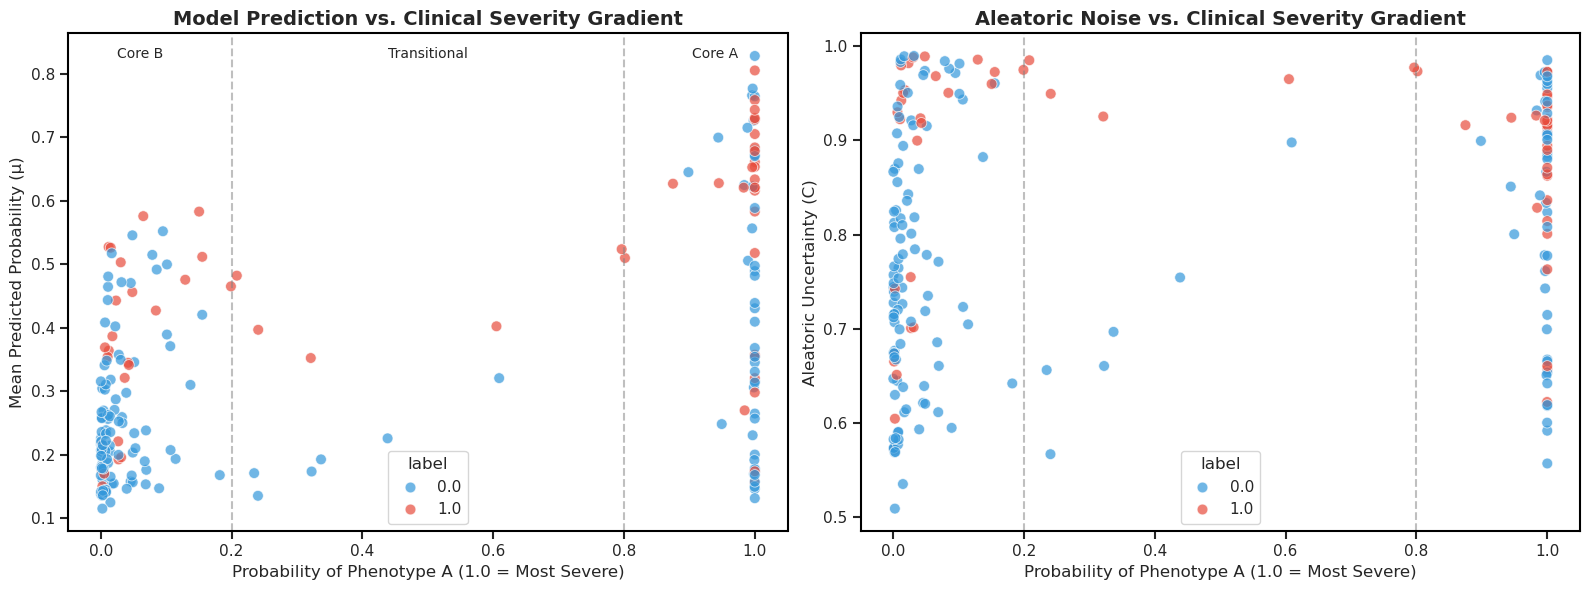

--- Distribution of Continuous Phenotypes ---
GMM_Category
Core Phenotype B (Uncomplicated)    127
Core Phenotype A (Complicated)       74
Transitional                         11
Name: count, dtype: int64


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

def extract_and_plot_gmm_probabilities(X_clinical, df_uncertainty):
    """
    Fits GMM (on PCA-reduced data), extracts continuous probabilities, and plots them.
    """
    # 1. Prepare Data
    imputer = SimpleImputer(strategy='median')
    X_scaled = StandardScaler().fit_transform(imputer.fit_transform(X_clinical))
    
    # 2. THE FIX: Apply PCA to prevent GMM probability collapse
    # Compressing the clinical space down to 2 dimensions forces the Gaussians to overlap
    pca = PCA(n_components=9, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # 3. Fit GMM on the PCA-reduced space
    gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
    clusters = gmm.fit_predict(X_pca)
    probabilities = gmm.predict_proba(X_pca)
    
    # 4. Identify which cluster is the "Advanced/Predictable" one (Phenotype A)
    ledd_cluster_0 = X_clinical['ledd'][clusters == 0].mean()
    ledd_cluster_1 = X_clinical['ledd'][clusters == 1].mean()
    
    if ledd_cluster_0 > ledd_cluster_1:
        advanced_idx = 0
    else:
        advanced_idx = 1
        
    # Extract the continuous probability of being in the Advanced/Complicated group
    prob_advanced = probabilities[:, advanced_idx]
    
    # 5. Merge into a new Analysis DataFrame
    analysis_df = df_uncertainty.copy()
    analysis_df['Prob_Phenotype_A'] = prob_advanced
    
    # Define categorical groups based on thresholds
    conditions = [
        (analysis_df['Prob_Phenotype_A'] > 0.80),
        (analysis_df['Prob_Phenotype_A'] >= 0.20) & (analysis_df['Prob_Phenotype_A'] <= 0.80),
        (analysis_df['Prob_Phenotype_A'] < 0.20)
    ]
    choices = ['Core Phenotype A (Complicated)', 'Transitional', 'Core Phenotype B (Uncomplicated)']
    analysis_df['GMM_Category'] = np.select(conditions, choices)
    
    # 6. Plot the Severity Gradient
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.set_facecolor('white')
    
    palette = {0.0: '#3498DB', 1.0: '#E74C3C'} # Blue for Healthy, Red for Incident
    
    # Plot 1: Probability vs. Mean Prediction (mu)
    sns.scatterplot(
        data=analysis_df, x='Prob_Phenotype_A', y='mu', hue='label',
        palette=palette, alpha=0.7, s=60, edgecolor='w', ax=ax1
    )
    ax1.set_title('Model Prediction vs. Clinical Severity Gradient', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Probability of Phenotype A (1.0 = Most Severe)', fontsize=12)
    ax1.set_ylabel('Mean Predicted Probability (μ)', fontsize=12)
    ax1.axvline(0.2, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(0.8, color='gray', linestyle='--', alpha=0.5)
    ax1.text(0.1, 0.95, 'Core B', ha='center', transform=ax1.transAxes)
    ax1.text(0.5, 0.95, 'Transitional', ha='center', transform=ax1.transAxes)
    ax1.text(0.9, 0.95, 'Core A', ha='center', transform=ax1.transAxes)
    
    # Plot 2: Probability vs. Aleatoric Uncertainty
    sns.scatterplot(
        data=analysis_df, x='Prob_Phenotype_A', y='C_Aleatoric', hue='label',
        palette=palette, alpha=0.7, s=60, edgecolor='w', ax=ax2
    )
    ax2.set_title('Aleatoric Noise vs. Clinical Severity Gradient', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Probability of Phenotype A (1.0 = Most Severe)', fontsize=12)
    ax2.set_ylabel('Aleatoric Uncertainty (C)', fontsize=12)
    ax2.axvline(0.2, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(0.8, color='gray', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Print the distribution
    print("--- Distribution of Continuous Phenotypes ---")
    print(analysis_df['GMM_Category'].value_counts())
    
    return analysis_df

# Execute 
# (Assuming your dataframe is called filtered_full_training_preds_cal_models and has 'mu', 'C_Aleatoric', 'label')
df_with_probs = extract_and_plot_gmm_probabilities(X_clinical=X_clinical, df_uncertainty=uncertainty_results)

CBRC

In [24]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, matthews_corrcoef

def explore_class_conditioned_evolution(df, uncertainty_col='H_Total', rates=[0, 25, 50]):
    """
    Calculates TP, TN, FP, FN, and MCC using a CLASS-CONDITIONED REJECTION rule 
    applied globally, then audits the survival rates locally by phenotype.
    """
    results = []
    
    # Make sure we have a binary prediction column
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    phenotypes = sorted(df['Phenotype'].unique())
    
    for rate in rates:
        if rate > 0:
            # ------------------------------------------------------------------
            # THE CORE UPGRADE: Class-Conditioned Rejection (Applied Globally)
            # ------------------------------------------------------------------
            # 1. Split the global dataframe by PREDICTED class
            pos_pool = df[df['y_pred'] == 1].copy()
            neg_pool = df[df['y_pred'] == 0].copy()
            
            # 2. Calculate the drop quotas proportionally for EACH class
            n_drop_pos = int(len(pos_pool) * (rate / 100.0))
            n_drop_neg = int(len(neg_pool) * (rate / 100.0))
            
            # 3. Sort by uncertainty and drop the most uncertain inside each class
            if n_drop_pos > 0:
                kept_pos = pos_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_pos:]
            else:
                kept_pos = pos_pool
                
            if n_drop_neg > 0:
                kept_neg = neg_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_neg:]
            else:
                kept_neg = neg_pool
            
            # 4. Recombine the surviving patients back into a single global cohort
            global_kept = pd.concat([kept_pos, kept_neg])
            # ------------------------------------------------------------------
            
        else:
            global_kept = df.copy()
            
        # 5. Audit the results locally (by phenotype) to prove it fixes Subgroup B
        for pheno in phenotypes:
            pheno_kept = global_kept[global_kept['Phenotype'] == pheno]
            
            y_true = pheno_kept['label']
            y_pred = pheno_kept['y_pred']
            
            # Safely calculate confusion matrix even if classes are missing
            labels_present = np.unique(np.concatenate((y_true, y_pred))) if len(pheno_kept) > 0 else []
            
            if len(labels_present) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
                mcc = matthews_corrcoef(y_true, y_pred)
            elif len(labels_present) == 1:
                # If only one class is predicted/present, manually count
                tp = sum((y_true == 1) & (y_pred == 1))
                tn = sum((y_true == 0) & (y_pred == 0))
                fp = sum((y_true == 0) & (y_pred == 1))
                fn = sum((y_true == 1) & (y_pred == 0))
                mcc = 0.0
            else:
                tp = tn = fp = fn = 0
                mcc = 0.0
                
            results.append({
                'Phenotype': pheno[:11] + '...', # Shorten for clean display
                'Rejection (%)': rate,
                'Total Kept': len(pheno_kept),
                'TP': tp,
                'FP': fp,
                'TN': tn,
                'FN': fn,
                'MCC': round(mcc, 3) if not pd.isna(mcc) else 0.0
            })
            
    # Format as a clean DataFrame
    results_df = pd.DataFrame(results)
    
    # Print formatted output for the presentation
    print("="*85)
    print("CLASS-CONDITIONED REJECTION: CONFUSION MATRIX EVOLUTION")
    print("="*85)
    print(results_df.to_string(index=False))
    print("="*85)
    
    return results_df

explore_class_conditioned_evolution(uncertainty_results, uncertainty_col='H_Total', rates=[0, 25, 50])


CLASS-CONDITIONED REJECTION: CONFUSION MATRIX EVOLUTION
     Phenotype  Rejection (%)  Total Kept  TP  FP  TN  FN   MCC
Phenotype A...              0          77  23  16  29   9 0.358
Phenotype B...              0         135   6   4 101  24 0.257
Phenotype A...             25          61  20  15  21   5 0.381
Phenotype B...             25          99   2   0  85  12 0.354
Phenotype A...             50          39  14  11  12   2 0.407
Phenotype B...             50          68   0   0  59   9 0.000


,Phenotype,Rejection (%),Total Kept,TP,FP,TN,FN,MCC
0,Phenotype A...,0,77,23,16,29,9,0.358
1,Phenotype B...,0,135,6,4,101,24,0.257
2,Phenotype A...,25,61,20,15,21,5,0.381
3,Phenotype B...,25,99,2,0,85,12,0.354
4,Phenotype A...,50,39,14,11,12,2,0.407
5,Phenotype B...,50,68,0,0,59,9,0.000


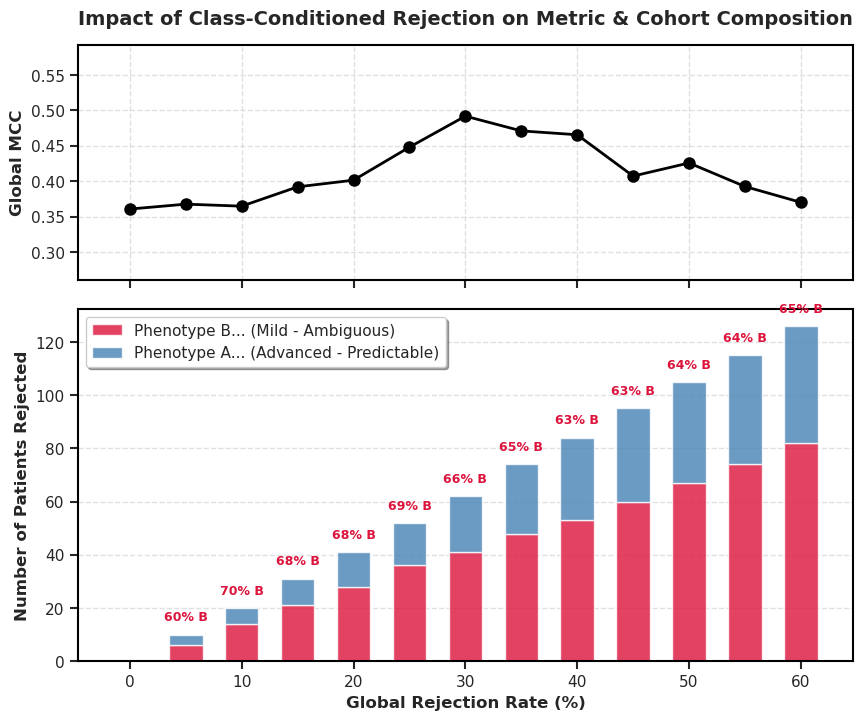

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef

def plot_ccr_biological_impact(df, uncertainty_col='C_Aleatoric', max_rate=50, step=5):
    """
    Simulates Class-Conditioned Rejection from 0% to max_rate%.
    Plots the Global MCC (Top) and the Biological Makeup of the Rejected Patients (Bottom).
    """
    # Ensure binary predictions exist
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    rates = list(range(0, max_rate + step, step))
    
    mcc_scores = []
    rejected_A = []
    rejected_B = []
    
    phenotypes = sorted(df['Phenotype'].unique())
    # Assuming Phenotype[0] is Advanced (A) and Phenotype[1] is Mild (B)
    pheno_A_name = phenotypes[0] 
    pheno_B_name = phenotypes[1]
    
    for rate in rates:
        if rate == 0:
            global_kept = df.copy()
            global_rejected = pd.DataFrame(columns=df.columns)
        else:
            # 1. Split globally by predicted class
            pos_pool = df[df['y_pred'] == 1].copy()
            neg_pool = df[df['y_pred'] == 0].copy()
            
            # 2. Drop proportionally based on uncertainty
            n_drop_pos = int(len(pos_pool) * (rate / 100.0))
            n_drop_neg = int(len(neg_pool) * (rate / 100.0))
            
            # Identify the dropped patients
            dropped_pos = pos_pool.sort_values(by=uncertainty_col, ascending=False).iloc[:n_drop_pos] if n_drop_pos > 0 else pd.DataFrame()
            dropped_neg = neg_pool.sort_values(by=uncertainty_col, ascending=False).iloc[:n_drop_neg] if n_drop_neg > 0 else pd.DataFrame()
            
            # Identify the kept patients
            kept_pos = pos_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_pos:] if n_drop_pos > 0 else pos_pool
            kept_neg = neg_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_neg:] if n_drop_neg > 0 else neg_pool
            
            global_kept = pd.concat([kept_pos, kept_neg])
            global_rejected = pd.concat([dropped_pos, dropped_neg])
            
        # Calculate Global MCC
        y_true = global_kept['label']
        y_pred = global_kept['y_pred']
        
        labels_present = np.unique(np.concatenate((y_true, y_pred))) if len(global_kept) > 0 else []
        if len(labels_present) > 1:
            mcc = matthews_corrcoef(y_true, y_pred)
        else:
            mcc = 0.0
            
        mcc_scores.append(mcc)
        
        # Count who got rejected
        count_A = len(global_rejected[global_rejected['Phenotype'] == pheno_A_name])
        count_B = len(global_rejected[global_rejected['Phenotype'] == pheno_B_name])
        
        rejected_A.append(count_A)
        rejected_B.append(count_B)

    # ==========================================
    # PLOTTING THE DASHBOARD
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1.5]})
    fig.subplots_adjust(hspace=0.1)
    
    # --- Top Panel: Global MCC Stability ---
    ax1.plot(rates, mcc_scores, marker='o', color='black', linewidth=2, markersize=8)
    ax1.set_ylabel('Global MCC', fontsize=12, fontweight='bold')
    ax1.set_title('Impact of Class-Conditioned Rejection on Metric & Cohort Composition', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.set_ylim([max(0, min(mcc_scores)-0.1), max(mcc_scores) + 0.1])
    
    # --- Bottom Panel: Who is being rejected? (Stacked Bar) ---
    bar_width = 3
    ax2.bar(rates, rejected_B, width=bar_width, label=f'{pheno_B_name[:11]}... (Mild - Ambiguous)', color='crimson', alpha=0.8)
    ax2.bar(rates, rejected_A, width=bar_width, bottom=rejected_B, label=f'{pheno_A_name[:11]}... (Advanced - Predictable)', color='steelblue', alpha=0.8)
    
    ax2.set_xlabel('Global Rejection Rate (%)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Patients Rejected', fontsize=12, fontweight='bold')
    ax2.grid(True, axis='y', linestyle='--', alpha=0.6)
    
    # Annotate the bars with the percentage of Phenotype B
    for i, rate in enumerate(rates):
        total_dropped = rejected_A[i] + rejected_B[i]
        if total_dropped > 0:
            pct_B = (rejected_B[i] / total_dropped) * 100
            ax2.text(rate, total_dropped + (max(rejected_A + rejected_B)*0.05), 
                     f"{pct_B:.0f}% B", ha='center', va='bottom', fontsize=9, fontweight='bold', color='crimson')

    ax2.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
    
    plt.show()

# To run it:
plot_ccr_biological_impact(uncertainty_results, uncertainty_col='H_Total', max_rate=60, step=5)

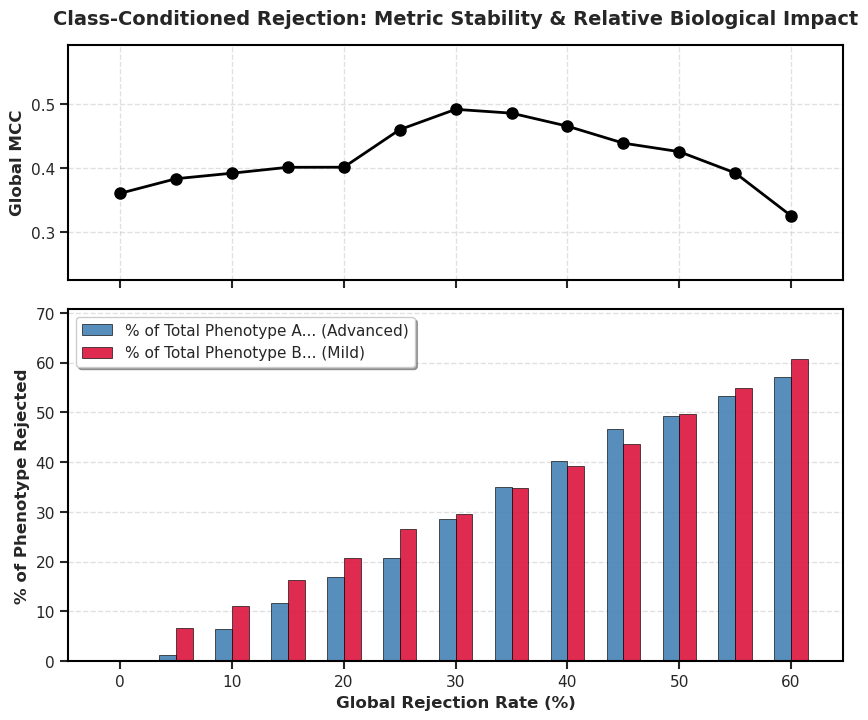

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef

def plot_ccr_biological_impact(df, uncertainty_col='C_Aleatoric', max_rate=50, step=5):
    """
    Simulates Class-Conditioned Rejection from 0% to max_rate%.
    Plots the Global MCC (Top) and the Relative % of each Phenotype Rejected (Bottom).
    """
    # Ensure binary predictions exist
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    rates = list(range(0, max_rate + step, step))
    
    mcc_scores = []
    rejected_A_pct = []
    rejected_B_pct = []
    
    phenotypes = sorted(df['Phenotype'].unique())
    # Assuming Phenotype[0] is Advanced (A) and Phenotype[1] is Mild (B)
    pheno_A_name = phenotypes[0] 
    pheno_B_name = phenotypes[1]
    
    # Calculate the exact base sizes of both clusters
    total_A_in_dataset = len(df[df['Phenotype'] == pheno_A_name])
    total_B_in_dataset = len(df[df['Phenotype'] == pheno_B_name])
    
    for rate in rates:
        if rate == 0:
            global_kept = df.copy()
            global_rejected = pd.DataFrame(columns=df.columns)
        else:
            # 1. Split globally by predicted class
            pos_pool = df[df['y_pred'] == 1].copy()
            neg_pool = df[df['y_pred'] == 0].copy()
            
            # 2. Drop proportionally based on uncertainty
            n_drop_pos = int(len(pos_pool) * (rate / 100.0))
            n_drop_neg = int(len(neg_pool) * (rate / 100.0))
            
            # Identify the dropped patients
            dropped_pos = pos_pool.sort_values(by=uncertainty_col, ascending=False).iloc[:n_drop_pos] if n_drop_pos > 0 else pd.DataFrame(columns=df.columns)
            dropped_neg = neg_pool.sort_values(by=uncertainty_col, ascending=False).iloc[:n_drop_neg] if n_drop_neg > 0 else pd.DataFrame(columns=df.columns)
            
            # Identify the kept patients
            kept_pos = pos_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_pos:] if n_drop_pos > 0 else pos_pool
            kept_neg = neg_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_neg:] if n_drop_neg > 0 else neg_pool
            
            # Recombine
            global_kept = pd.concat([kept_pos, kept_neg])
            global_rejected = pd.concat([dropped_pos, dropped_neg])
            
        # --- Calculate Global MCC ---
        y_true = global_kept['label']
        y_pred = global_kept['y_pred']
        
        labels_present = np.unique(np.concatenate((y_true, y_pred))) if len(global_kept) > 0 else []
        if len(labels_present) > 1:
            mcc = matthews_corrcoef(y_true, y_pred)
        else:
            mcc = 0.0
            
        mcc_scores.append(mcc)
        
        # --- Calculate Relative Rejection Percentages ---
        count_A = len(global_rejected[global_rejected['Phenotype'] == pheno_A_name])
        count_B = len(global_rejected[global_rejected['Phenotype'] == pheno_B_name])
        
        # What percentage of the total cluster was thrown away?
        pct_A = (count_A / total_A_in_dataset) * 100 if total_A_in_dataset > 0 else 0
        pct_B = (count_B / total_B_in_dataset) * 100 if total_B_in_dataset > 0 else 0
        
        rejected_A_pct.append(pct_A)
        rejected_B_pct.append(pct_B)

    # ==========================================
    # PLOTTING THE DASHBOARD
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1.5]})
    fig.subplots_adjust(hspace=0.1)
    
    # --- Top Panel: Global MCC Stability ---
    ax1.plot(rates, mcc_scores, marker='o', color='black', linewidth=2, markersize=8)
    ax1.set_ylabel('Global MCC', fontsize=12, fontweight='bold')
    ax1.set_title('Class-Conditioned Rejection: Metric Stability & Relative Biological Impact', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Dynamically set y-limits for the top plot so the line doesn't hit the ceiling
    ax1.set_ylim([max(0, min(mcc_scores)-0.1), max(mcc_scores) + 0.1])
    
    # --- Bottom Panel: Relative Rejection (Side-by-Side Bar Chart) ---
    bar_width = 1.5
    r1 = np.array(rates) - bar_width/2  # Shift Blue bars to the left
    r2 = np.array(rates) + bar_width/2  # Shift Red bars to the right
    
    ax2.bar(r1, rejected_A_pct, width=bar_width, label=f'% of Total {pheno_A_name[:11]}... (Advanced)', color='steelblue', alpha=0.9, edgecolor='black', linewidth=0.5)
    ax2.bar(r2, rejected_B_pct, width=bar_width, label=f'% of Total {pheno_B_name[:11]}... (Mild)', color='crimson', alpha=0.9, edgecolor='black', linewidth=0.5)
    
    ax2.set_xlabel('Global Rejection Rate (%)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('% of Phenotype Rejected', fontsize=12, fontweight='bold')
    ax2.grid(True, axis='y', linestyle='--', alpha=0.6)
    
    # Make sure Y-axis goes up to at least the highest percentage rejected (maybe up to 100%)
    max_pct = max(max(rejected_A_pct), max(rejected_B_pct))
    ax2.set_ylim([0, min(100, max_pct + 10)]) 
    
    ax2.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
    
    plt.show()

# To run it on your dataframe:
plot_ccr_biological_impact(uncertainty_results, uncertainty_col='C_Aleatoric', max_rate=60, step=5)

In [28]:
df_analysis = X_clinical.copy()
df_analysis['Phenotype_cluster'] = phenotype_labels
df_analysis['mu'] = uncertainty_results['mu']
df_analysis['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
df_analysis['label'] = uncertainty_results['label']
df_analysis['y_pred'] = uncertainty_results['y_pred']
df_analysis['H_Total'] = uncertainty_results['H_Total']
df_analysis['sigma'] = uncertainty_results['sigma']
df_analysis['C_Aleatoric'] = uncertainty_results['C_Aleatoric']


In [29]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

def profile_rejected_patients(df, features_to_analyze, uncertainty_col='H_Total', rate=15):
    """
    Applies CCR at a specific rate, isolates Phenotype B, and statistically 
    compares the clinical features of the Rejected vs. Kept patients.
    """
    # 1. Apply Global CCR
    pos_pool = df[df['y_pred'] == 1].copy()
    neg_pool = df[df['y_pred'] == 0].copy()
    
    n_drop_pos = int(len(pos_pool) * (rate / 100.0))
    n_drop_neg = int(len(neg_pool) * (rate / 100.0))
    
    # Mark patients as Rejected (1) or Kept (0)
    pos_pool = pos_pool.sort_values(by=uncertainty_col, ascending=False)
    pos_pool['is_rejected'] = [1]*n_drop_pos + [0]*(len(pos_pool) - n_drop_pos)
    
    neg_pool = neg_pool.sort_values(by=uncertainty_col, ascending=False)
    neg_pool['is_rejected'] = [1]*n_drop_neg + [0]*(len(neg_pool) - n_drop_neg)
    
    global_df = pd.concat([pos_pool, neg_pool])
    
    # 2. Isolate Phenotype B (Mild)
    phenotypes = sorted(df['Phenotype_cluster'].unique())
    pheno_B_name = phenotypes[1] # Assuming 1 is the Mild phenotype
    pheno_B_df = global_df[global_df['Phenotype_cluster'] == pheno_B_name]
    
    print(f"--- CLINICAL PROFILE OF PHENOTYPE B AT {rate}% GLOBAL REJECTION ---")
    print(f"Total B Patients: {len(pheno_B_df)}")
    print(f"Rejected B Patients: {sum(pheno_B_df['is_rejected'] == 1)}")
    print(f"Kept B Patients: {sum(pheno_B_df['is_rejected'] == 0)}\n")
    
    # 3. Statistical Comparison of Features
    results = []
    for feature in features_to_analyze:
        if feature in pheno_B_df.columns:
            rejected_vals = pheno_B_df[pheno_B_df['is_rejected'] == 1][feature].dropna()
            kept_vals = pheno_B_df[pheno_B_df['is_rejected'] == 0][feature].dropna()
            
            # Calculate means
            mean_rej = rejected_vals.mean()
            mean_kept = kept_vals.mean()
            
            # Non-parametric test for statistical significance
            if len(rejected_vals) > 0 and len(kept_vals) > 0:
                stat, p_val = mannwhitneyu(rejected_vals, kept_vals, alternative='two-sided')
            else:
                p_val = np.nan
                
            results.append({
                'Clinical Feature': feature,
                'Mean (Rejected)': round(mean_rej, 2),
                'Mean (Kept)': round(mean_kept, 2),
                'p-value': round(p_val, 4)
            })
            
    profile_df = pd.DataFrame(results)
    
    # Sort by the most statistically significant differences
    profile_df = profile_df.sort_values(by='p-value')
    print(profile_df.to_string(index=False))
    return profile_df

# Example usage (replace the list with your actual clinical column names):
# features = ['AGE', 'DISEASE_DURATION', 'UPDRS_III_TOTAL', 'LEDD', 'UPDRS_II_TOTAL']
profile_rejected_patients(df_analysis, X_clinical.columns.tolist(), rate=15)

--- CLINICAL PROFILE OF PHENOTYPE B AT 15% GLOBAL REJECTION ---
Total B Patients: 135
Rejected B Patients: 21
Kept B Patients: 114

        Clinical Feature  Mean (Rejected)  Mean (Kept)  p-value
          LevodopaBinary             0.95         0.46   0.0000
           LevodopaYears             3.10         0.81   0.0000
                    ledd           366.62       127.09   0.0000
       MotorFluctuations             0.14         0.00   0.0001
               IMAOYears             3.00         0.80   0.0002
        DiseaseYearsAtBL             0.57         0.18   0.0004
   AgonistiDopaminaYears             2.55         1.34   0.0520
                Hyposmia             0.17         0.40   0.0570
  AgonistiDopaminaBinary             0.62         0.77   0.1406
               Education            10.57        11.81   0.1475
  YearsSymptomsDiagnosis             0.80         1.39   0.1512
                  Gender             0.48         0.32   0.1567
                 Anxiety            

,Clinical Feature,Mean (Rejected),Mean (Kept),p-value
15,LevodopaBinary,0.95,0.46,0.0000
14,LevodopaYears,3.10,0.81,0.0000
25,ledd,366.62,127.09,0.0000
4,MotorFluctuations,0.14,0.00,0.0001
18,IMAOYears,3.00,0.80,0.0002
21,DiseaseYearsAtBL,0.57,0.18,0.0004
16,AgonistiDopaminaYears,2.55,1.34,0.0520
12,Hyposmia,0.17,0.40,0.0570
17,AgonistiDopaminaBinary,0.62,0.77,0.1406
24,Education,10.57,11.81,0.1475


In [30]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

def test_ccr_biological_validity(df, feature_cols, uncertainty_col='C_Aleatoric', rate=20, k=5):
    """
    Tests if CCR is biologically valid by checking the raw 'Neighborhood Purity' 
    of the rejected patients vs the kept patients, ignoring the model's predictions.
    """
    # 1. Calculate the Objective Biological Purity (Independent of the Model)
    # Scale the raw baseline features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[feature_cols].fillna(df[feature_cols].median()))
    y_true = df['label'].values
    
    # Find the K nearest neighbors for every patient based ONLY on clinical features
    knn = NearestNeighbors(n_neighbors=k+1) # +1 because the patient is their own nearest neighbor
    knn.fit(X_scaled)
    distances, indices = knn.kneighbors(X_scaled)
    
    # Calculate Purity: What % of a patient's neighbors share their exact ground-truth outcome?
    purities = []
    for i in range(len(df)):
        neighbor_indices = indices[i][1:] # Skip the first one (the patient themselves)
        neighbor_labels = y_true[neighbor_indices]
        patient_label = y_true[i]
        purity = np.mean(neighbor_labels == patient_label) * 100
        purities.append(purity)
        
    df['Biological_Purity'] = purities
    
    # 2. Apply the CCR Math 
    pos_pool = df[df['y_pred'] == 1].copy()
    neg_pool = df[df['y_pred'] == 0].copy()
    
    n_drop_pos = int(len(pos_pool) * (rate / 100.0))
    n_drop_neg = int(len(neg_pool) * (rate / 100.0))
    
    # Tag patients as Rejected or Kept
    pos_pool = pos_pool.sort_values(by=uncertainty_col, ascending=False)
    pos_pool['is_rejected'] = [1]*n_drop_pos + [0]*(len(pos_pool) - n_drop_pos)
    
    neg_pool = neg_pool.sort_values(by=uncertainty_col, ascending=False)
    neg_pool['is_rejected'] = [1]*n_drop_neg + [0]*(len(neg_pool) - n_drop_neg)
    
    global_df = pd.concat([pos_pool, neg_pool])
    
    # 3. The Moment of Truth: Did CCR throw away the objectively worst biology?
    rejected_purity = global_df[global_df['is_rejected'] == 1]['Biological_Purity']
    kept_purity = global_df[global_df['is_rejected'] == 0]['Biological_Purity']
    
    mean_rej_purity = rejected_purity.mean()
    mean_kept_purity = kept_purity.mean()
    
    stat, p_val = mannwhitneyu(rejected_purity, kept_purity, alternative='less')
    
    print(f"--- BIOLOGICAL VALIDITY TEST AT {rate}% REJECTION ---")
    print(f"Average Purity of KEPT Patients:     {mean_kept_purity:.1f}%")
    print(f"Average Purity of REJECTED Patients: {mean_rej_purity:.1f}%\n")
    print(f"Statistical Difference (p-value):    {p_val:.5f}")
    
    if p_val < 0.05:
        print("\nVERDICT: CCR is BIOLOGICALLY VALID.")
        print("The algorithm successfully targeted and removed patients whose raw baseline")
        print("features were objectively tangled and contradictory, independent of the model's math.")
    else:
        print("\nVERDICT: CCR is a MATH HACK.")
        print("The rejected patients had the same biological clarity as the kept patients.")
        print("The algorithm just sacrificed them to balance the MCC equation.")

# How to run it:
# List all your raw clinical features (UPDRS, Age, LEDD, etc.)
# features = ['AGE', 'DISEASE_DURATION', 'UPDRS_III_TOTAL', 'LEDD', 'IMAOYears', 'LevodopaBinary', 'Hyposmia']
test_ccr_biological_validity(df_analysis, X_clinical.columns.tolist(), rate=20)

--- BIOLOGICAL VALIDITY TEST AT 20% REJECTION ---
Average Purity of KEPT Patients:     66.2%
Average Purity of REJECTED Patients: 51.2%

Statistical Difference (p-value):    0.00151

VERDICT: CCR is BIOLOGICALLY VALID.
The algorithm successfully targeted and removed patients whose raw baseline
features were objectively tangled and contradictory, independent of the model's math.


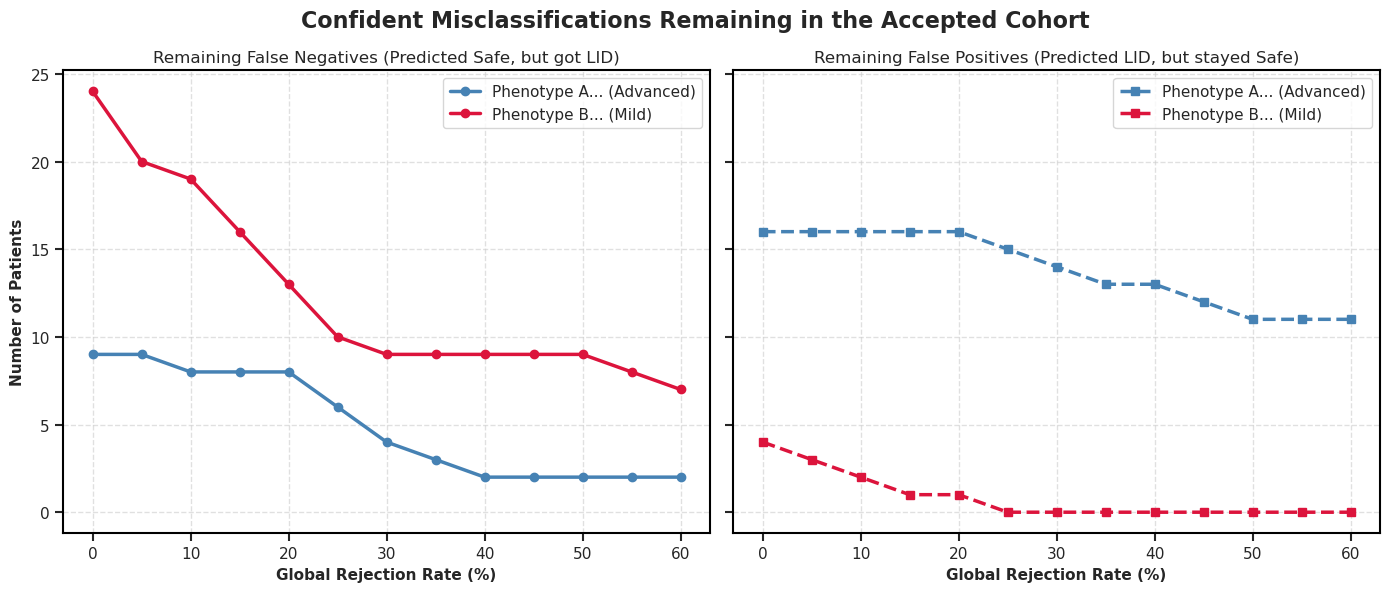

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confident_error_decay(df, uncertainty_col='C_Aleatoric', max_rate=40, step=5):
    """
    Tracks the absolute number of Confident Misclassifications (False Negatives 
    and False Positives) remaining in the KEPT cohort across rejection rates.
    """
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    rates = list(range(0, max_rate + step, step))
    phenotypes = sorted(df['Phenotype'].unique())
    pheno_A_name = phenotypes[0] 
    pheno_B_name = phenotypes[1]
    
    # Tracking dictionaries
    errors = {
        'A_FN': [], 'A_FP': [],
        'B_FN': [], 'B_FP': []
    }
    
    for rate in rates:
        if rate == 0:
            global_kept = df.copy()
        else:
            # Apply Class-Conditioned Rejection globally
            pos_pool = df[df['y_pred'] == 1].copy()
            neg_pool = df[df['y_pred'] == 0].copy()
            
            n_drop_pos = int(len(pos_pool) * (rate / 100.0))
            n_drop_neg = int(len(neg_pool) * (rate / 100.0))
            
            kept_pos = pos_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_pos:] if n_drop_pos > 0 else pos_pool
            kept_neg = neg_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_neg:] if n_drop_neg > 0 else neg_pool
            
            global_kept = pd.concat([kept_pos, kept_neg])
            
        # Calculate remaining errors for each phenotype
        for pheno in phenotypes:
            pheno_kept = global_kept[global_kept['Phenotype'] == pheno]
            y_true = pheno_kept['label']
            y_pred = pheno_kept['y_pred']
            
            labels_present = np.unique(np.concatenate((y_true, y_pred))) if len(pheno_kept) > 0 else []
            
            if len(labels_present) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            elif len(labels_present) == 1:
                fp = sum((y_true == 0) & (y_pred == 1))
                fn = sum((y_true == 1) & (y_pred == 0))
            else:
                fp = fn = 0
                
            if pheno == pheno_A_name:
                errors['A_FN'].append(fn)
                errors['A_FP'].append(fp)
            else:
                errors['B_FN'].append(fn)
                errors['B_FP'].append(fp)

    # ==========================================
    # PLOTTING
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle('Confident Misclassifications Remaining in the Accepted Cohort', fontsize=16, fontweight='bold')
    
    # Left Panel: False Negatives (The "Missed" LID cases)
    ax1.plot(rates, errors['A_FN'], marker='o', color='steelblue', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax1.plot(rates, errors['B_FN'], marker='o', color='crimson', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax1.set_title('Remaining False Negatives (Predicted Safe, but got LID)', fontsize=12)
    ax1.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Right Panel: False Positives (The "False Alarms")
    ax2.plot(rates, errors['A_FP'], marker='s', color='steelblue', linestyle='--', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax2.plot(rates, errors['B_FP'], marker='s', color='crimson', linestyle='--', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax2.set_title('Remaining False Positives (Predicted LID, but stayed Safe)', fontsize=12)
    ax2.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Run it:
plot_confident_error_decay(uncertainty_results, uncertainty_col='C_Aleatoric', max_rate=60, step=5)

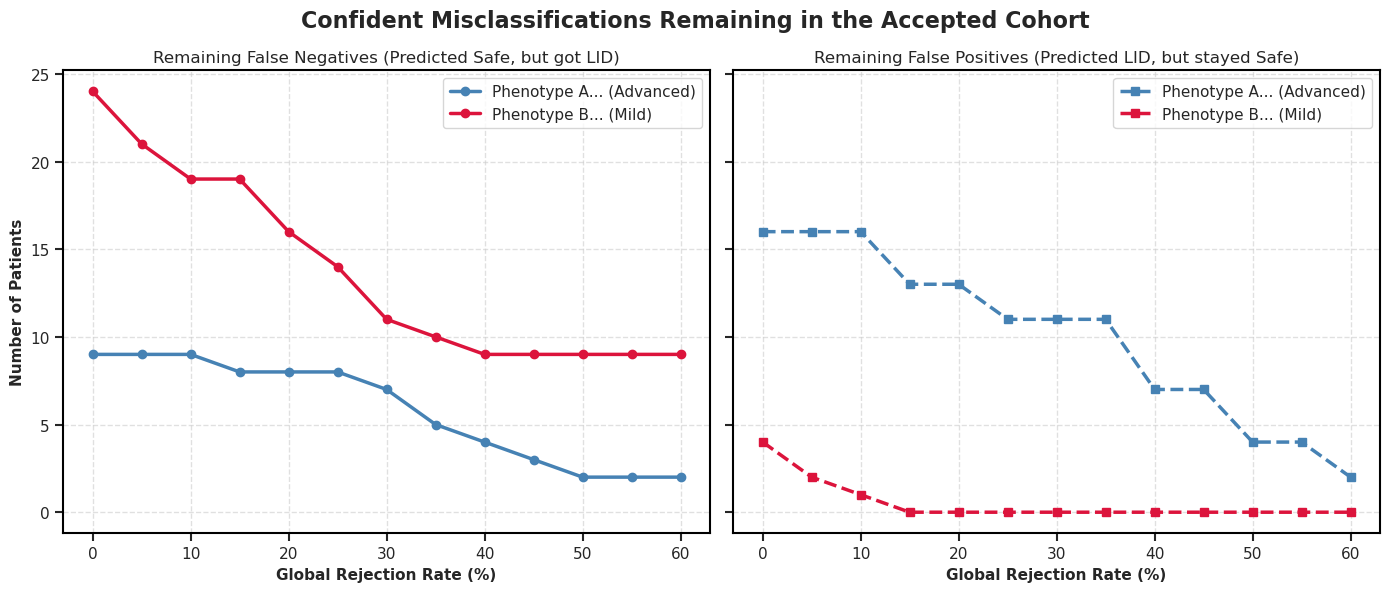

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confident_error_decay(df, uncertainty_col='C_Aleatoric', max_rate=40, step=5):
    """
    Tracks the absolute number of Confident Misclassifications (False Negatives 
    and False Positives) remaining in the KEPT cohort across rejection rates.
    """
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    rates = list(range(0, max_rate + step, step))
    phenotypes = sorted(df['Phenotype'].unique())
    pheno_A_name = phenotypes[0] 
    pheno_B_name = phenotypes[1]
    
    # Tracking dictionaries
    errors = {
        'A_FN': [], 'A_FP': [],
        'B_FN': [], 'B_FP': []
    }
    
    for rate in rates:
        if rate == 0:
            global_kept = df.copy()
        else:
            # Apply Rejection globally
            n_drop_global = int(len(df) * (rate / 100.0))
            global_kept = df.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_global:] if n_drop_global > 0 else df.copy()

                        
        # Calculate remaining errors for each phenotype
        for pheno in phenotypes:
            pheno_kept = global_kept[global_kept['Phenotype'] == pheno]
            y_true = pheno_kept['label']
            y_pred = pheno_kept['y_pred']
            
            labels_present = np.unique(np.concatenate((y_true, y_pred))) if len(pheno_kept) > 0 else []
            
            if len(labels_present) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            elif len(labels_present) == 1:
                fp = sum((y_true == 0) & (y_pred == 1))
                fn = sum((y_true == 1) & (y_pred == 0))
            else:
                fp = fn = 0
                
            if pheno == pheno_A_name:
                errors['A_FN'].append(fn)
                errors['A_FP'].append(fp)
            else:
                errors['B_FN'].append(fn)
                errors['B_FP'].append(fp)

    # ==========================================
    # PLOTTING
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle('Confident Misclassifications Remaining in the Accepted Cohort', fontsize=16, fontweight='bold')
    
    # Left Panel: False Negatives (The "Missed" LID cases)
    ax1.plot(rates, errors['A_FN'], marker='o', color='steelblue', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax1.plot(rates, errors['B_FN'], marker='o', color='crimson', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax1.set_title('Remaining False Negatives (Predicted Safe, but got LID)', fontsize=12)
    ax1.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Right Panel: False Positives (The "False Alarms")
    ax2.plot(rates, errors['A_FP'], marker='s', color='steelblue', linestyle='--', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax2.plot(rates, errors['B_FP'], marker='s', color='crimson', linestyle='--', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax2.set_title('Remaining False Positives (Predicted LID, but stayed Safe)', fontsize=12)
    ax2.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Run it:
plot_confident_error_decay(uncertainty_results, uncertainty_col='C_Aleatoric', max_rate=60, step=5)

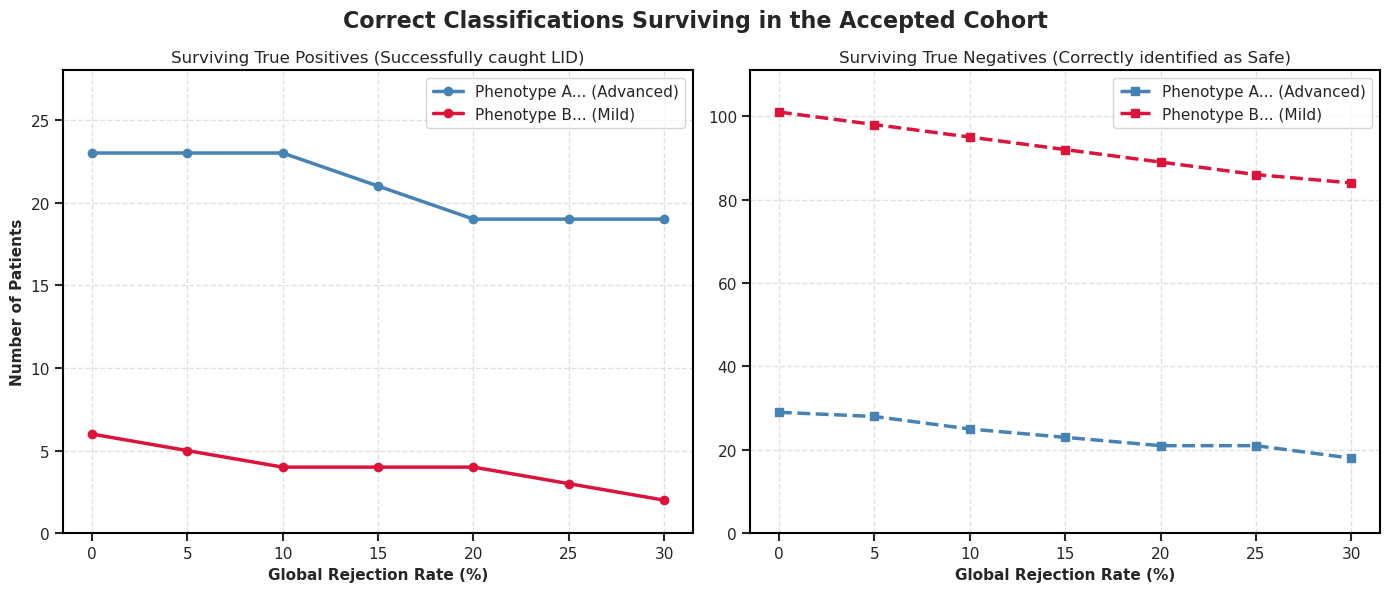

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_correct_predictions_survival(df, uncertainty_col='C_Aleatoric', max_rate=40, step=5):
    """
    Tracks the absolute number of Correct Classifications (True Positives 
    and True Negatives) surviving in the KEPT cohort across rejection rates.
    """
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    rates = list(range(0, max_rate + step, step))
    phenotypes = sorted(df['Phenotype'].unique())
    pheno_A_name = phenotypes[0] 
    pheno_B_name = phenotypes[1]
    
    # Tracking dictionaries
    correct = {
        'A_TP': [], 'A_TN': [],
        'B_TP': [], 'B_TN': []
    }
    
    for rate in rates:
        if rate == 0:
            global_kept = df.copy()
        else:
            # Apply Class-Conditioned Rejection globally
            pos_pool = df[df['y_pred'] == 1].copy()
            neg_pool = df[df['y_pred'] == 0].copy()
            
            n_drop_pos = int(len(pos_pool) * (rate / 100.0))
            n_drop_neg = int(len(neg_pool) * (rate / 100.0))
            
            kept_pos = pos_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_pos:] if n_drop_pos > 0 else pos_pool
            kept_neg = neg_pool.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_neg:] if n_drop_neg > 0 else neg_pool
            
            global_kept = pd.concat([kept_pos, kept_neg])
            
        # Calculate surviving correct predictions for each phenotype
        for pheno in phenotypes:
            pheno_kept = global_kept[global_kept['Phenotype'] == pheno]
            y_true = pheno_kept['label']
            y_pred = pheno_kept['y_pred']
            
            labels_present = np.unique(np.concatenate((y_true, y_pred))) if len(pheno_kept) > 0 else []
            
            if len(labels_present) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            elif len(labels_present) == 1:
                tp = sum((y_true == 1) & (y_pred == 1))
                tn = sum((y_true == 0) & (y_pred == 0))
            else:
                tp = tn = 0
                
            if pheno == pheno_A_name:
                correct['A_TP'].append(tp)
                correct['A_TN'].append(tn)
            else:
                correct['B_TP'].append(tp)
                correct['B_TN'].append(tn)

    # ==========================================
    # PLOTTING
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Correct Classifications Surviving in the Accepted Cohort', fontsize=16, fontweight='bold')
    
    # Left Panel: True Positives (The crucial LID catches)
    ax1.plot(rates, correct['A_TP'], marker='o', color='steelblue', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax1.plot(rates, correct['B_TP'], marker='o', color='crimson', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax1.set_title('Surviving True Positives (Successfully caught LID)', fontsize=12)
    ax1.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Dynamically set y-axis to start at 0 so we can see the true scale
    max_tp = max(max(correct['A_TP']), max(correct['B_TP']))
    ax1.set_ylim([0, max_tp + 5])
    ax1.legend()

    # Right Panel: True Negatives (The correct safe diagnoses)
    ax2.plot(rates, correct['A_TN'], marker='s', color='steelblue', linestyle='--', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax2.plot(rates, correct['B_TN'], marker='s', color='crimson', linestyle='--', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax2.set_title('Surviving True Negatives (Correctly identified as Safe)', fontsize=12)
    ax2.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    max_tn = max(max(correct['A_TN']), max(correct['B_TN']))
    ax2.set_ylim([0, max_tn + 10])
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Run it:
plot_correct_predictions_survival(uncertainty_results, uncertainty_col='C_Aleatoric', max_rate=30, step=5)

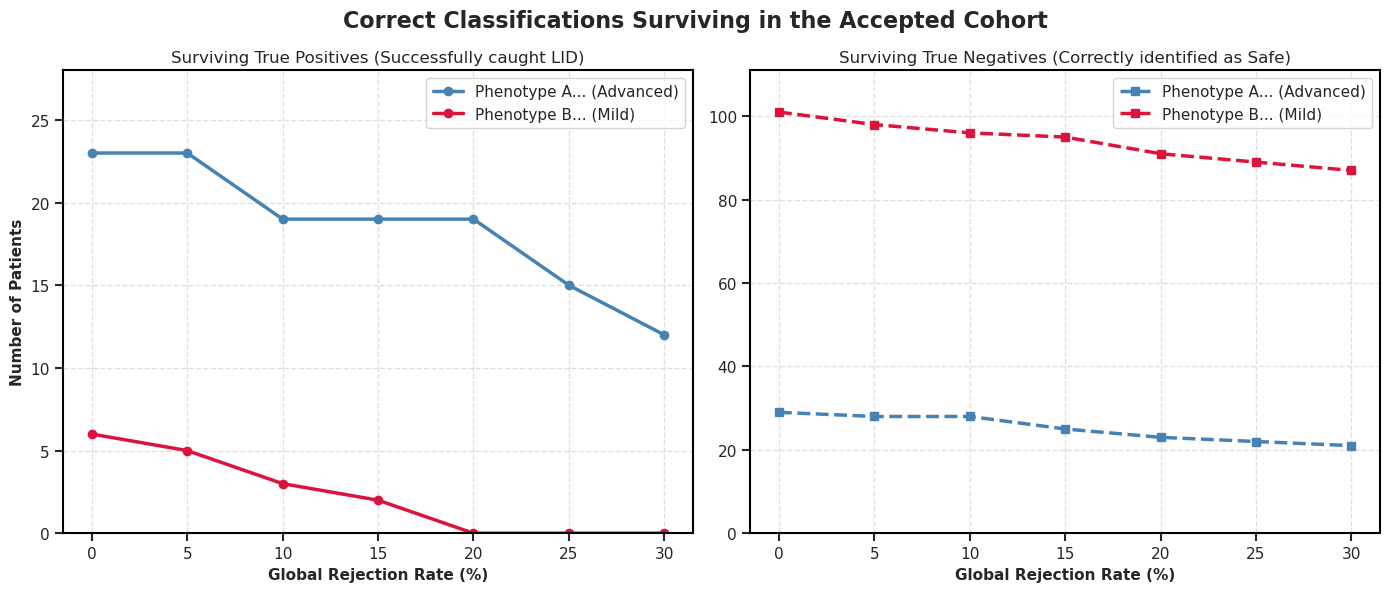

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_correct_predictions_survival(df, uncertainty_col='C_Aleatoric', max_rate=40, step=5):
    """
    Tracks the absolute number of Correct Classifications (True Positives 
    and True Negatives) surviving in the KEPT cohort across rejection rates.
    """
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    rates = list(range(0, max_rate + step, step))
    phenotypes = sorted(df['Phenotype'].unique())
    pheno_A_name = phenotypes[0] 
    pheno_B_name = phenotypes[1]
    
    # Tracking dictionaries
    correct = {
        'A_TP': [], 'A_TN': [],
        'B_TP': [], 'B_TN': []
    }
    
    for rate in rates:
        if rate == 0:
            global_kept = df.copy()
        else:
            # Apply Rejection globally
            n_drop_global = int(len(df) * (rate / 100.0))
            global_kept = df.sort_values(by=uncertainty_col, ascending=False).iloc[n_drop_global:] if n_drop_global > 0 else df.copy()

                        
            
        # Calculate surviving correct predictions for each phenotype
        for pheno in phenotypes:
            pheno_kept = global_kept[global_kept['Phenotype'] == pheno]
            y_true = pheno_kept['label']
            y_pred = pheno_kept['y_pred']
            
            labels_present = np.unique(np.concatenate((y_true, y_pred))) if len(pheno_kept) > 0 else []
            
            if len(labels_present) > 1:
                tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            elif len(labels_present) == 1:
                tp = sum((y_true == 1) & (y_pred == 1))
                tn = sum((y_true == 0) & (y_pred == 0))
            else:
                tp = tn = 0
                
            if pheno == pheno_A_name:
                correct['A_TP'].append(tp)
                correct['A_TN'].append(tn)
            else:
                correct['B_TP'].append(tp)
                correct['B_TN'].append(tn)

    # ==========================================
    # PLOTTING
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Correct Classifications Surviving in the Accepted Cohort', fontsize=16, fontweight='bold')
    
    # Left Panel: True Positives (The crucial LID catches)
    ax1.plot(rates, correct['A_TP'], marker='o', color='steelblue', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax1.plot(rates, correct['B_TP'], marker='o', color='crimson', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax1.set_title('Surviving True Positives (Successfully caught LID)', fontsize=12)
    ax1.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Dynamically set y-axis to start at 0 so we can see the true scale
    max_tp = max(max(correct['A_TP']), max(correct['B_TP']))
    ax1.set_ylim([0, max_tp + 5])
    ax1.legend()

    # Right Panel: True Negatives (The correct safe diagnoses)
    ax2.plot(rates, correct['A_TN'], marker='s', color='steelblue', linestyle='--', linewidth=2.5, label=f'{pheno_A_name[:11]}... (Advanced)')
    ax2.plot(rates, correct['B_TN'], marker='s', color='crimson', linestyle='--', linewidth=2.5, label=f'{pheno_B_name[:11]}... (Mild)')
    ax2.set_title('Surviving True Negatives (Correctly identified as Safe)', fontsize=12)
    ax2.set_xlabel('Global Rejection Rate (%)', fontsize=11, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    max_tn = max(max(correct['A_TN']), max(correct['B_TN']))
    ax2.set_ylim([0, max_tn + 10])
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Run it:
plot_correct_predictions_survival(uncertainty_results, uncertainty_col='C_Aleatoric', max_rate=30, step=5)

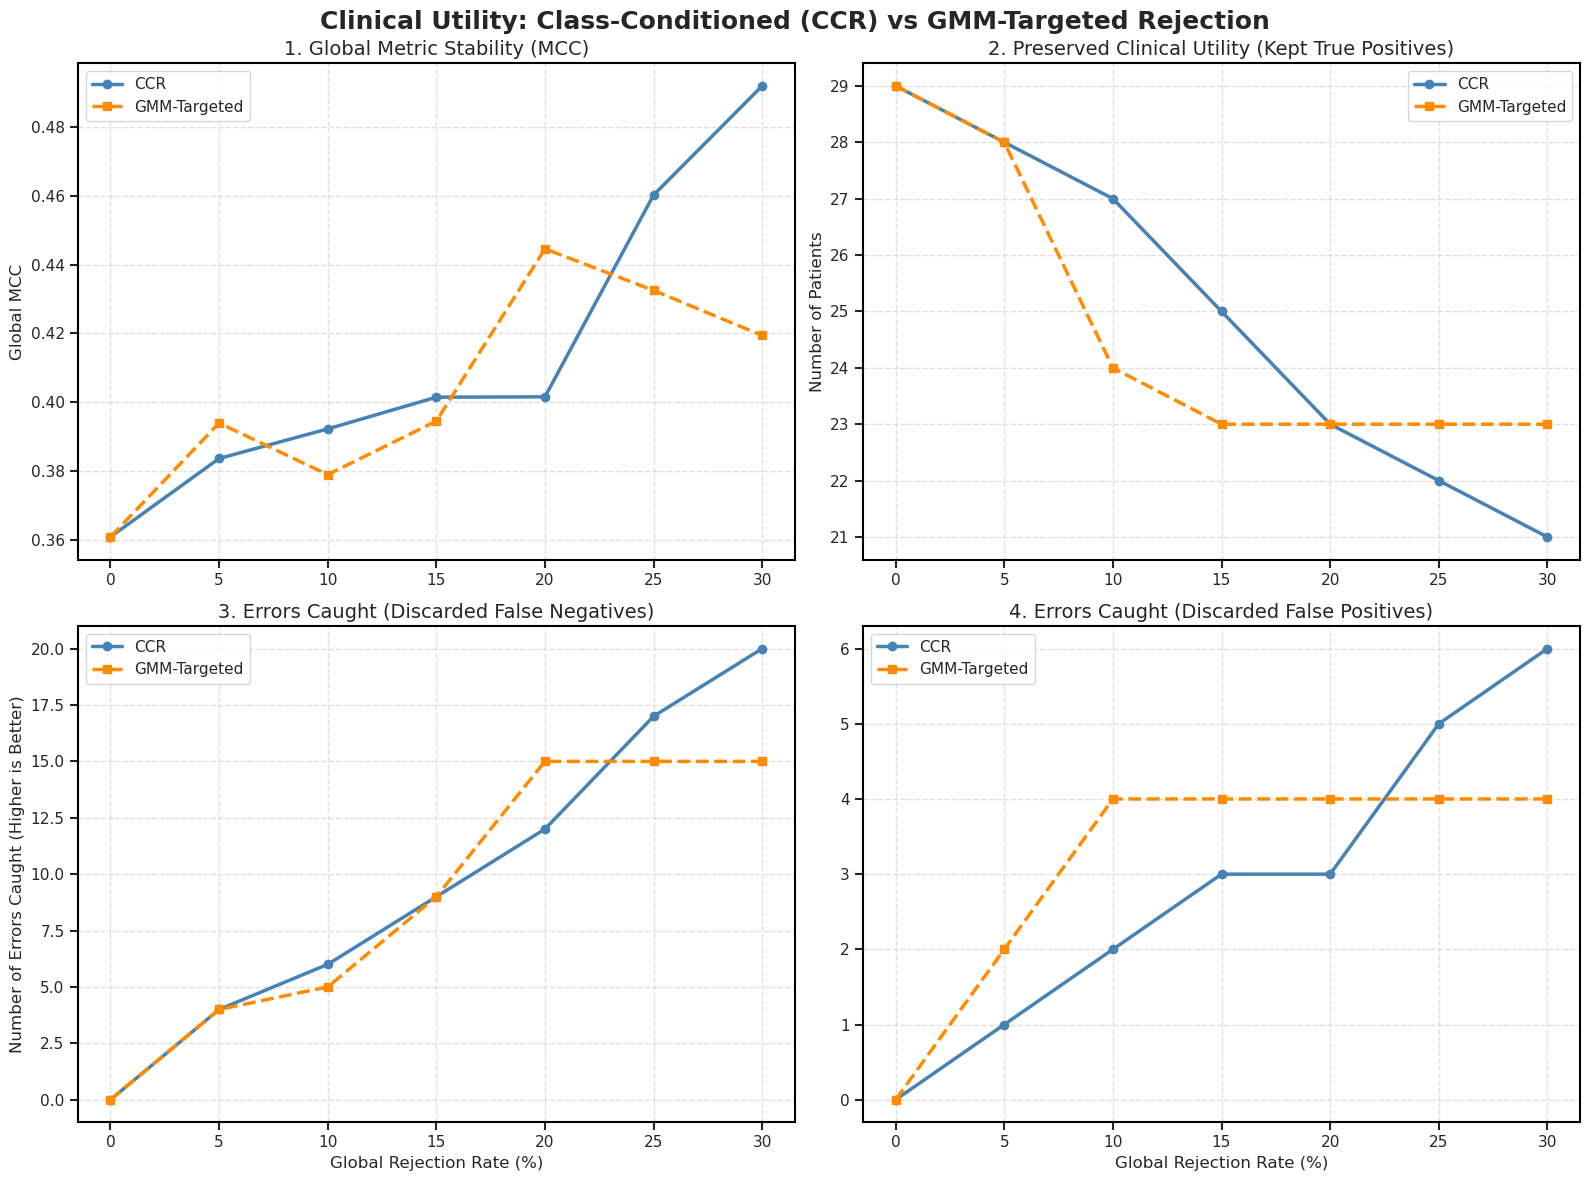

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, matthews_corrcoef

def compare_ccr_vs_gmm_rejection(df, uncertainty_col='C_Aleatoric', max_rate=30, step=5):
    """
    Simulates and compares Class-Conditioned Rejection (CCR) vs. GMM-Targeted Rejection.
    Compares MCC, Kept Correct Predictions (TP/TN), and Discarded Errors (FN/FP).
    """
    if 'y_pred' not in df.columns:
        df['y_pred'] = (df['mu'] >= 0.5).astype(int)
        
    rates = list(range(0, max_rate + step, step))
    phenotypes = sorted(df['Phenotype'].unique())
    pheno_B_name = phenotypes[1] # Assuming 1 is Mild (Subgroup B)
    
    # Tracking dictionaries for CCR
    ccr = {'MCC': [], 'Kept_TP': [], 'Kept_TN': [], 'Discarded_FN': [], 'Discarded_FP': []}
    
    # Tracking dictionaries for GMM-Targeted Rejection
    gmm = {'MCC': [], 'Kept_TP': [], 'Kept_TN': [], 'Discarded_FN': [], 'Discarded_FP': []}
    
    for rate in rates:
        n_drop_total = int(len(df) * (rate / 100.0))
        
        # ==========================================
        # METHOD 1: Class-Conditioned Rejection (CCR)
        # ==========================================
        if rate == 0:
            ccr_kept, ccr_dropped = df.copy(), pd.DataFrame(columns=df.columns)
        else:
            pos_pool = df[df['y_pred'] == 1].sort_values(by=uncertainty_col, ascending=False)
            neg_pool = df[df['y_pred'] == 0].sort_values(by=uncertainty_col, ascending=False)
            
            n_drop_pos = int(len(pos_pool) * (rate / 100.0))
            n_drop_neg = int(len(neg_pool) * (rate / 100.0))
            
            ccr_dropped = pd.concat([pos_pool.iloc[:n_drop_pos], neg_pool.iloc[:n_drop_neg]])
            ccr_kept = pd.concat([pos_pool.iloc[n_drop_pos:], neg_pool.iloc[n_drop_neg:]])
            
        # ==========================================
        # METHOD 2: GMM-Targeted Rejection
        # ==========================================
        if rate == 0:
            gmm_kept, gmm_dropped = df.copy(), pd.DataFrame(columns=df.columns)
        else:
            # Sort ONLY Subgroup B by uncertainty and drop the total required amount
            df_B = df[df['Phenotype'] == pheno_B_name].sort_values(by=uncertainty_col, ascending=False)
            df_A = df[df['Phenotype'] != pheno_B_name]
            
            # If rate is so high we exhaust Subgroup B, we take from A (rarely happens at <30%)
            gmm_dropped = df_B.iloc[:n_drop_total] if n_drop_total <= len(df_B) else pd.concat([df_B, df_A.sort_values(by=uncertainty_col, ascending=False).iloc[:n_drop_total-len(df_B)]])
            gmm_kept = df.drop(gmm_dropped.index)
            
        # --- CALCULATE METRICS ---
        for method_name, kept_df, dropped_df, track_dict in [('CCR', ccr_kept, ccr_dropped, ccr), ('GMM', gmm_kept, gmm_dropped, gmm)]:
            
            # MCC
            y_true_k = kept_df['label']
            y_pred_k = kept_df['y_pred']
            mcc = matthews_corrcoef(y_true_k, y_pred_k) if len(np.unique(np.concatenate((y_true_k, y_pred_k)))) > 1 else 0
            track_dict['MCC'].append(mcc)
            
            # Kept TP / TN
            if len(kept_df) > 0:
                tn_k, fp_k, fn_k, tp_k = confusion_matrix(y_true_k, y_pred_k, labels=[0,1]).ravel()
            else:
                tn_k = tp_k = 0
            track_dict['Kept_TP'].append(tp_k)
            track_dict['Kept_TN'].append(tn_k)
            
            # Discarded FN / FP (Errors caught by the filter)
            if len(dropped_df) > 0:
                y_true_d = dropped_df['label']
                y_pred_d = dropped_df['y_pred']
                tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_true_d, y_pred_d, labels=[0,1]).ravel()
            else:
                fp_d = fn_d = 0
            track_dict['Discarded_FN'].append(fn_d)
            track_dict['Discarded_FP'].append(fp_d)

    # ==========================================
    # PLOTTING THE DASHBOARD
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Clinical Utility: Class-Conditioned (CCR) vs GMM-Targeted Rejection', fontsize=18, fontweight='bold')
    
    # Define colors
    ccr_color = 'steelblue'
    gmm_color = 'darkorange'
    
    # 1. Global Metric (MCC)
    axes[0,0].plot(rates, ccr['MCC'], marker='o', color=ccr_color, linewidth=2.5, label='CCR')
    axes[0,0].plot(rates, gmm['MCC'], marker='s', color=gmm_color, linewidth=2.5, linestyle='--', label='GMM-Targeted')
    axes[0,0].set_title('1. Global Metric Stability (MCC)', fontsize=14)
    axes[0,0].set_ylabel('Global MCC')
    axes[0,0].legend()
    axes[0,0].grid(True, linestyle='--', alpha=0.6)

    # 2. Kept True Positives (The Gold Mine)
    axes[0,1].plot(rates, ccr['Kept_TP'], marker='o', color=ccr_color, linewidth=2.5, label='CCR')
    axes[0,1].plot(rates, gmm['Kept_TP'], marker='s', color=gmm_color, linewidth=2.5, linestyle='--', label='GMM-Targeted')
    axes[0,1].set_title('2. Preserved Clinical Utility (Kept True Positives)', fontsize=14)
    axes[0,1].set_ylabel('Number of Patients')
    axes[0,1].legend()
    axes[0,1].grid(True, linestyle='--', alpha=0.6)

    # 3. Discarded False Negatives (Prevented Disasters) - HIGHER IS BETTER
    axes[1,0].plot(rates, ccr['Discarded_FN'], marker='o', color=ccr_color, linewidth=2.5, label='CCR')
    axes[1,0].plot(rates, gmm['Discarded_FN'], marker='s', color=gmm_color, linewidth=2.5, linestyle='--', label='GMM-Targeted')
    axes[1,0].set_title('3. Errors Caught (Discarded False Negatives)', fontsize=14)
    axes[1,0].set_xlabel('Global Rejection Rate (%)')
    axes[1,0].set_ylabel('Number of Errors Caught (Higher is Better)')
    axes[1,0].legend()
    axes[1,0].grid(True, linestyle='--', alpha=0.6)

    # 4. Discarded False Positives (Prevented False Alarms) - HIGHER IS BETTER
    axes[1,1].plot(rates, ccr['Discarded_FP'], marker='o', color=ccr_color, linewidth=2.5, label='CCR')
    axes[1,1].plot(rates, gmm['Discarded_FP'], marker='s', color=gmm_color, linewidth=2.5, linestyle='--', label='GMM-Targeted')
    axes[1,1].set_title('4. Errors Caught (Discarded False Positives)', fontsize=14)
    axes[1,1].set_xlabel('Global Rejection Rate (%)')
    axes[1,1].legend()
    axes[1,1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run this on your dataframe:
compare_ccr_vs_gmm_rejection(uncertainty_results, uncertainty_col='C_Aleatoric', max_rate=30, step=5)